# Conservative Species List – SAC Analysis
## PanTHERIA Body-Mass Thresholds with Semi-Aquatic Exclusion & Introduced Species

This notebook builds on the original mass-threshold SAC analysis with a **more
conservative / restricted species list**:

1. **Semi-aquatic & aquatic species removed** from SSUSA observations
2. **Introduced species ranges included** in IUCN data (only domestics removed)
3. **Mass thresholds**: Unfiltered, >= 50 g, >= 100 g, >= 500 g, >= 1000 g
4. **Primary comparison focus**: 100 g vs 500 g

Uses **1 km deployment point-buffers** and array-level species accumulation curves.

In [1]:
import os

# Must set R path BEFORE importing rpy2
conda_env_path = "/home/hice1/kyan66/scratch/r_kernel"
os.environ['R_HOME'] = f"{conda_env_path}/lib/R"
os.environ['PATH'] = f"{conda_env_path}/bin:" + os.environ.get('PATH', '')
os.environ['LD_LIBRARY_PATH'] = f"{conda_env_path}/lib:" + os.environ.get('LD_LIBRARY_PATH', '')
print(f"R environment path configured: {os.environ['R_HOME']}")

R environment path configured: /home/hice1/kyan66/scratch/r_kernel/lib/R


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import random
import re
import geopandas as gpd

In [3]:
save_dir = '../data/ssusa'
os.makedirs(save_dir, exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

random.seed(42)
np.random.seed(42)

In [4]:
# ==============================================================================
# PARAMETER BLOCK  --  edit these values to change all downstream outputs
# ==============================================================================

# Mass thresholds in grams.  None = unfiltered baseline.
mass_thresholds = [None, 50, 100, 500, 1000]

# Point-buffer radius (km) around each camera deployment
point_buffer_km = 1.0

# File paths
iucn_path      = "../data/MAMMALS_TERRESTRIAL_ONLY/MAMMALS_TERRESTRIAL_ONLY.shp"
ssusa_path     = "../data/ssusa/cleaned_snapshot_usa_iucn.csv"
pantheria_path = "../data/PanTHERIA_1-0_WR05_Aug2008.txt"

# SAC settings
sac_permutations = 100   # number of permutations for method='random'

# Output file prefix (to distinguish from the original notebook outputs)
output_prefix = "conservative_global_comparison"

def threshold_label(t):
    """Human-readable label for a mass threshold."""
    return "Unfiltered (all species)" if t is None else f">= {t} g"

def threshold_filesafe(t):
    """File-safe string for a threshold (used in output filenames)."""
    return "unfiltered" if t is None else f"{t}g"

In [5]:
df = pd.read_csv(ssusa_path, low_memory=False)
print(f"SSUSA records loaded: {len(df)}")
df.head()

SSUSA records loaded: 698887


,Year,Project,Camera_Trap_Array,Deployment_ID,Sequence_ID,Start_Time,End_Time,Class,Order,Family,Genus,Species,Common_Name,Sci_Name,Age,Sex,Group_Size,Site_Name,Start_Date,End_Date,Survey_Nights,Latitude,Longitude,Habitat,Development_Level,Feature_Type
0,2019,Snapshot USA 2019,Crupi,AK_Forest_Chilkat_Preserve_1,d58722s1,2019-08-31 06:50:00,2019-08-31 06:50:00,mammalia,carnivora,ursidae,ursus,arctos,brown bear,ursus arctos,unknown,unknown,1,AK_Forest_Crupi_21_dep_01,2019-08-31,2019-11-03,64.0,59.42643,-136.2225,forest,wild,water source
1,2019,Snapshot USA 2019,Crupi,AK_Forest_Chilkat_Preserve_1,d58722s2,2019-08-31 14:15:00,2019-08-31 14:17:00,mammalia,carnivora,ursidae,ursus,arctos,brown bear,ursus arctos,unknown,unknown,1,AK_Forest_Crupi_21_dep_01,2019-08-31,2019-11-03,64.0,59.42643,-136.2225,forest,wild,water source
2,2019,Snapshot USA 2019,Crupi,AK_Forest_Chilkat_Preserve_1,d58722s3,2019-08-31 18:22:00,2019-08-31 18:22:00,mammalia,carnivora,ursidae,ursus,arctos,brown bear,ursus arctos,unknown,unknown,1,AK_Forest_Crupi_21_dep_01,2019-08-31,2019-11-03,64.0,59.42643,-136.2225,forest,wild,water source
3,2019,Snapshot USA 2019,Crupi,AK_Forest_Chilkat_Preserve_1,d58722s4,2019-08-31 20:58:00,2019-08-31 20:58:00,mammalia,carnivora,ursidae,ursus,arctos,brown bear,ursus arctos,adult,female,1,AK_Forest_Crupi_21_dep_01,2019-08-31,2019-11-03,64.0,59.42643,-136.2225,forest,wild,water source
4,2019,Snapshot USA 2019,Crupi,AK_Forest_Chilkat_Preserve_1,d58722s4,2019-08-31 20:58:00,2019-08-31 20:58:00,mammalia,carnivora,ursidae,ursus,arctos,brown bear,ursus arctos,juvenile,unknown,2,AK_Forest_Crupi_21_dep_01,2019-08-31,2019-11-03,64.0,59.42643,-136.2225,forest,wild,water source


In [6]:
def _pick_column(columns, candidates):
    """Return the first matching column name (case-insensitive)."""
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def _normalize_species(value):
    """Lowercase, trim, collapse whitespace."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    text = str(value).strip()
    text = re.sub(r"\s+", " ", text).lower()
    return text

In [7]:
def get_species_matrix(df, unit_col, species_col='Sci_Name', all_units=None):
    """Binary presence/absence matrix (sampling-unit x species)."""
    valid_data = df.dropna(subset=[unit_col]).copy()
    valid_data = valid_data.dropna(subset=[species_col])
    valid_data = valid_data[valid_data[species_col] != ""]

    matrix = pd.crosstab(valid_data[unit_col], valid_data[species_col])
    matrix = (matrix > 0).astype(int)

    if all_units is not None:
        unit_index = pd.Index(pd.Series(all_units).dropna().tolist(), name=unit_col).unique()
        matrix = matrix.reindex(unit_index, fill_value=0)

    if matrix.index.name is None:
        matrix.index.name = unit_col

    return matrix.sort_index()


def build_global_comparison(snapshot_df, iucn_df, species_col='Sci_Name'):
    """Build the global overlap table for one threshold."""
    snapshot_global = (
        snapshot_df[[species_col]]
        .dropna()
        .drop_duplicates()
        .rename(columns={species_col: 'species'})
    )
    snapshot_global['in_snapshot'] = True

    iucn_global = (
        iucn_df[[species_col]]
        .dropna()
        .drop_duplicates()
        .rename(columns={species_col: 'species'})
    )
    iucn_global['in_iucn'] = True

    global_joint = snapshot_global.merge(iucn_global, on='species', how='outer', sort=True)
    if global_joint.empty:
        return pd.DataFrame(columns=['species', 'in_snapshot', 'in_iucn', 'category'])

    global_joint['in_snapshot'] = global_joint['in_snapshot'].fillna(False).astype(bool)
    global_joint['in_iucn'] = global_joint['in_iucn'].fillna(False).astype(bool)
    global_joint['category'] = np.select(
        [
            global_joint['in_snapshot'] & global_joint['in_iucn'],
            global_joint['in_snapshot'] & ~global_joint['in_iucn'],
            ~global_joint['in_snapshot'] & global_joint['in_iucn'],
        ],
        ['both', 'snapshot_only', 'iucn_only'],
        default='unknown',
    )

    category_order = pd.Categorical(
        global_joint['category'],
        categories=['both', 'snapshot_only', 'iucn_only', 'unknown'],
        ordered=True,
    )
    global_joint['category'] = category_order
    global_joint = global_joint.sort_values(['category', 'species']).reset_index(drop=True)
    global_joint['category'] = global_joint['category'].astype(str)
    return global_joint


def species_accumulation(matrix, method='exact', permutations=100,
                         conditioned=True, gamma='jack1', w=None):
    """Wrapper around R vegan::specaccum."""
    vegan = importr('vegan')
    with localconverter(pandas2ri.converter + robjects.default_converter):
        r_matrix = pandas2ri.py2rpy(matrix)
        kwargs = {
            'method': method,
            'permutations': permutations,
            'conditioned': conditioned,
            'gamma': gamma
        }
        if w is not None:
            kwargs['w'] = robjects.FloatVector(w)
        result = vegan.specaccum(r_matrix, **kwargs)

    with localconverter(pandas2ri.converter + robjects.default_converter):
        sites = np.array(robjects.r('as.numeric')(result.rx2('sites')))
        richness = np.array(robjects.r('as.numeric')(result.rx2('richness')))
        try:
            sd_val = result.rx2('sd')
            sd = np.array(robjects.r('as.numeric')(sd_val)) if sd_val != robjects.NULL else np.zeros_like(richness)
        except Exception:
            sd = np.zeros_like(richness)
    return {'sites': sites, 'richness': richness, 'sd': sd, 'method': method}


def plot_threshold_sac(acc_obs, acc_iucn, n_units, n_sp_obs, n_sp_iucn,
                       label, buffer_km):
    """SSUSA-vs-IUCN SAC figure for one threshold."""
    fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
    plt.style.use('seaborn-v0_8-whitegrid')

    x1, y1, sd1 = acc_obs['sites'], acc_obs['richness'], acc_obs['sd']
    me1 = max(1, len(x1) // 30)
    if sd1 is not None and np.any(sd1 > 0):
        ax.fill_between(x1, y1 - 2 * sd1, y1 + 2 * sd1,
                        color='#2E7D32', alpha=0.15)
    ax.plot(x1, y1, color='#2E7D32', linewidth=3,
            marker='o', markersize=4, markerfacecolor='white',
            markeredgewidth=2, markeredgecolor='#2E7D32',
            markevery=me1,
            label='SSUSA Species (SSUSA Detections)', zorder=3)

    x2, y2, sd2 = acc_iucn['sites'], acc_iucn['richness'], acc_iucn['sd']
    me2 = max(1, len(x2) // 30)
    if sd2 is not None and np.any(sd2 > 0):
        ax.fill_between(x2, y2 - 2 * sd2, y2 + 2 * sd2,
                        color='#6A1B9A', alpha=0.15)
    ax.plot(x2, y2, color='#6A1B9A', linewidth=3, linestyle='--',
            marker='s', markersize=4, markerfacecolor='white',
            markeredgewidth=2, markeredgecolor='#6A1B9A',
            markevery=me2,
            label='IUCN Expected Species (Point Buffers)', zorder=3)

    ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel('Sampling Units (Arrays)', fontsize=16,
                  fontweight='bold', labelpad=12)
    ax.set_ylabel('Accumulated Species Richness', fontsize=16,
                  fontweight='bold', labelpad=12)
    ax.set_title(f'Species Accumulation Curves [{label}]\n'
                 f'({buffer_km} km deployment point buffers, array-level)',
                 fontsize=18, fontweight='bold', pad=20)
    ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=2)

    legend = ax.legend(loc='lower right', frameon=True, fancybox=True,
                       shadow=True, fontsize=13, framealpha=0.97,
                       edgecolor='#333333', facecolor='white')
    legend.get_frame().set_linewidth(1.5)

    textstr = (f'Arrays: {n_units}\n'
               f'SSUSA: {n_sp_obs} species\n'
               f'IUCN: {n_sp_iucn} species')
    props = dict(boxstyle='round,pad=0.8', facecolor='white',
                 edgecolor='#333333', linewidth=1.5, alpha=0.95)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('#333333')

    plt.tight_layout()
    plt.show()

    print(f"\n  SSUSA richness : {acc_obs['richness'][-1]:.0f}")
    print(f"  IUCN richness     : {acc_iucn['richness'][-1]:.0f}")
    print(f"  Detection gap     : "
          f"{acc_iucn['richness'][-1] - acc_obs['richness'][-1]:.0f} species")




In [8]:
# ----------------------------
# Load PanTHERIA dataset
# ----------------------------
pantheria = pd.read_csv(pantheria_path, sep="\t")
pantheria = pantheria.replace(-999, np.nan)
pantheria = pantheria.replace(-999.00, np.nan)

# Keep only species name and body mass
pantheria = pantheria[["MSW05_Binomial", "5-1_AdultBodyMass_g"]].copy()
pantheria.columns = ["Sci_Name_pantheria", "Adult_Body_Mass_g"]

# Normalize species names
pantheria["Sci_Name_pantheria"] = pantheria["Sci_Name_pantheria"].map(
    _normalize_species
)
pantheria = pantheria.drop_duplicates(subset=["Sci_Name_pantheria"])

print(f"PanTHERIA species loaded: {len(pantheria)}")
print(f"  with body mass  : {pantheria['Adult_Body_Mass_g'].notna().sum()}")
print(f"  missing body mass: {pantheria['Adult_Body_Mass_g'].isna().sum()}")
pantheria.head()

PanTHERIA species loaded: 5416
  with body mass  : 3542
  missing body mass: 1874


,Sci_Name_pantheria,Adult_Body_Mass_g
0,camelus dromedarius,492714.47
1,canis adustus,10392.49
2,canis aureus,9658.70
3,canis latrans,11989.10
4,canis lupus,31756.51


In [9]:
# ----------------------------
# Taxonomy harmonization (SSUSA / IUCN -> current names; current names -> PanTHERIA MSW05)
# ----------------------------
taxonomy_remap = {
    'mustela frenata': 'neogale frenata',
    'myodes gapperi': 'clethrionomys gapperi',
    'neovison vison': 'neogale vison',
    'pekania pennanti': 'martes pennanti',
}
pantheria_name_map = {new_name: old_name for old_name, new_name in taxonomy_remap.items()}


def harmonize_taxonomy(name):
    """Map SSUSA / IUCN species names to the current comparison taxonomy."""
    if name is None:
        return None
    return taxonomy_remap.get(name, name)


def pantheria_lookup_name(name):
    """Map current comparison names back to PanTHERIA MSW05 names."""
    if name is None:
        return None
    return pantheria_name_map.get(name, name)


def get_eligible_species(threshold, all_species, pantheria_df):
    """Return the set of species passing a mass threshold.

    Rules
    -----
    * threshold=None  -> keep all species (unfiltered baseline).
    * Otherwise       -> keep only if Adult_Body_Mass_g is not missing
                         AND Adult_Body_Mass_g >= threshold.
    """
    if threshold is None:
        print(f"  Threshold: Unfiltered -- all {len(all_species)} species retained")
        return set(all_species)

    species_df = pd.DataFrame({'species': sorted(all_species)})
    species_df['pantheria_key'] = species_df['species'].map(pantheria_lookup_name)

    merged = species_df.merge(
        pantheria_df,
        left_on='pantheria_key',
        right_on='Sci_Name_pantheria',
        how='left',
    )

    mass = merged['Adult_Body_Mass_g']
    has_mass = mass.notna()
    meets_thresh = has_mass & (mass >= threshold)

    eligible = set(merged.loc[meets_thresh, 'species'])

    n_with_mass = int(has_mass.sum())
    n_by_mass = int(meets_thresh.sum())
    n_missing = int((~has_mass).sum())
    n_removed = len(all_species) - len(eligible)

    print(f"  Threshold: >= {threshold} g")
    print(f"    Species with mass data : {n_with_mass}")
    print(f"    Retained by mass       : {n_by_mass}")
    print(f"    Excluded (mass missing): {n_missing}")
    print(f"    Removed (below thresh) : {n_removed}")
    print(f"    Total eligible         : {len(eligible)} / {len(all_species)}")
    return eligible

In [10]:
def plot_threshold_overlay(curve_results, buffer_km):
    """One subplot per mass threshold, color by source."""
    if not curve_results:
        return

    n = len(curve_results)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), dpi=300, sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()
    plt.style.use('seaborn-v0_8-whitegrid')

    # Colors for source
    colors = {'SSUSA': '#1B9E77', 'IUCN': '#D95F02'}

    for ax, result in zip(axes, curve_results):
        acc_obs = result['acc_obs']
        acc_iucn = result['acc_iucn']

        ax.plot(
            acc_obs['sites'], acc_obs['richness'],
            color=colors['SSUSA'], linewidth=2.0, label='SSUSA'
        )
        ax.plot(
            acc_iucn['sites'], acc_iucn['richness'],
            color=colors['IUCN'], linewidth=2.0, linestyle='--', label='IUCN'
        )

        ax.set_title(result['label'], fontsize=13, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.set_axisbelow(True)

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)
            spine.set_edgecolor('#333333')

    # Common labels
    fig.text(0.5, 0.04, 'Sampling Units (Arrays)', ha='center', fontsize=14, fontweight='bold')
    fig.text(0.04, 0.5, 'Accumulated Species Richness', va='center', rotation='vertical',
             fontsize=14, fontweight='bold')

    # Shared legend (deduplicated)
    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.legend(
        by_label.values(), by_label.keys(),
        loc='upper center',
        ncol=2,
        frameon=True,
        fontsize=11,
        bbox_to_anchor=(0.5, 0.98),
        title='Source'
    )

    # fig.suptitle(
    #     f'Species Accumulation Curves Across Mass Thresholds\n'
    #     f'({buffer_km} km deployment point buffers, array-level)',
    #     fontsize=16, fontweight='bold', y=0.99
    # )

    plt.tight_layout(rect=[0.06, 0.06, 0.94, 0.92])
    plt.show()

In [11]:
def plot_threshold_pair_comparison(curve_results, buffer_km,
                                   labels_to_compare=(">= 100 g", ">= 500 g")):
    """Overlay a small set of thresholds (e.g., 100 g vs 500 g) for direct comparison."""
    # Filter only the thresholds of interest
    label_set = set(labels_to_compare)
    subset = [r for r in curve_results if r['label'] in label_set]
    if len(subset) < 2:
        print("Not enough thresholds found for comparison.")
        return

    fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
    plt.style.use('seaborn-v0_8-whitegrid')

    # Color by threshold
    threshold_colors = {
        'Unfiltered (all species)': '#1B9E77',
        '>= 50 g': '#D95F02',
        '>= 100 g': '#7570B3',
        '>= 500 g': '#E6AB02',
        '>= 1000 g': '#E7298A',
    }

    for result in subset:
        color = threshold_colors.get(result['label'], '#4C78A8')
        acc_obs = result['acc_obs']
        acc_iucn = result['acc_iucn']

        ax.plot(
            acc_obs['sites'], acc_obs['richness'],
            color=color, linewidth=2.2, linestyle='-',
            label=f"SSUSA | {result['label']}",
        )
        ax.plot(
            acc_iucn['sites'], acc_iucn['richness'],
            color=color, linewidth=2.2, linestyle='--',
            label=f"IUCN | {result['label']}",
        )

    ax.set_xlabel('Sampling Units (Arrays)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Accumulated Species Richness', fontsize=13, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='major', labelsize=11)

    ax.legend(loc='best', frameon=True, fontsize=10, ncol=2)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_edgecolor('#333333')

    plt.tight_layout()
    plt.show()

In [12]:
# ----------------------------
# Load IUCN species range data
# ----------------------------
iucn = gpd.read_file(iucn_path)
if iucn.crs is None:
    iucn = iucn.set_crs("EPSG:4326")
else:
    iucn = iucn.to_crs("EPSG:4326")

iucn = iucn[iucn.geometry.notnull()].copy()
if not iucn.is_valid.all():
    iucn["geometry"] = iucn.geometry.buffer(0)

print(f"IUCN polygons loaded: {len(iucn)}")

IUCN polygons loaded: 12703


In [13]:
# ----------------------------
# Align species naming between IUCN and Snapshot USA
# ----------------------------
# IUCN species column
iucn_species_col = _pick_column(
    iucn.columns,
    ['SCI_NAME', 'Sci_Name', 'binomial', 'scientific', 'species', 'Species'],
)
if iucn_species_col is None:
    raise ValueError('Could not detect IUCN species name column.')

iucn['Sci_Name'] = iucn[iucn_species_col].map(_normalize_species).map(harmonize_taxonomy)
iucn = iucn.dropna(subset=['Sci_Name'])

# Keep origin column for introduced-species filtering (1=Native, 2=Reintroduced, 3=Introduced)
origin_col = _pick_column(iucn.columns, ['origin', 'ORIGIN', 'Origin'])
cols_to_keep = ['Sci_Name', 'geometry']
if origin_col is not None:
    cols_to_keep.append(origin_col)
    print(f"IUCN origin column found: '{origin_col}'")
    print(f"  Origin value counts:\n{iucn[origin_col].value_counts().sort_index().to_string()}")
iucn = iucn[cols_to_keep]

# SSUSA species column
df_species_col = _pick_column(
    df.columns,
    ['Sci_Name', 'SciName', 'Scientific_Name', 'species', 'Species'],
)
if df_species_col is None:
    raise ValueError('Could not detect SSUSA species column.')
if df_species_col != 'Sci_Name':
    df['Sci_Name'] = df[df_species_col]
df['Sci_Name'] = df['Sci_Name'].map(_normalize_species).map(harmonize_taxonomy)

print(f"\nIUCN unique species : {iucn['Sci_Name'].nunique()}")
print(f"SSUSA unique species: {df['Sci_Name'].nunique()}")

IUCN origin column found: 'origin'
  Origin value counts:
origin
1    12275
2      118
3      214
4       16
5       68
6       12

IUCN unique species : 5683
SSUSA unique species: 113


# Allow Introduced Species in IUCN Data

The original notebook removes **all** non-native species from IUCN ranges.
Here we take a more inclusive approach: **keep introduced wild species** but
still remove domestic animals and commensal pest rodents.

In [14]:
# ----------------------------
# Remove ONLY domestic / commensal species from IUCN ranges
# (Keep introduced wild species like sus scrofa, boselaphus tragocamelus, etc.)
# ----------------------------
species_domestic_only = [
    # Domestic animals
    'canis lupus familiaris', 'felis catus', 'bos taurus', 'equus caballus',
    'ovis aries', 'sus scrofa domesticus', 'capra hircus', 'equus asinus',
    # Commensal pest rodents
    'rattus norvegicus', 'rattus rattus', 'mus musculus',
]
species_domestic_set = set(
    pd.Series(species_domestic_only).str.lower().str.strip().tolist()
)

n_before = iucn['Sci_Name'].nunique()
iucn = iucn[~iucn["Sci_Name"].isin(species_domestic_set)].copy()
n_after = iucn['Sci_Name'].nunique()

print(f"IUCN species before domestic removal: {n_before}")
print(f"IUCN species after domestic removal : {n_after}")
print(f"Domestics/commensals removed        : {n_before - n_after}")
print()

# Show which introduced wild species are NOW included (vs original notebook)
original_removed = {
    'boselaphus tragocamelus', 'lama glama', 'lariscus insignis',
    'oryx gazella', 'urva javanica', 'sus scrofa',
}
now_kept = original_removed - species_domestic_set
kept_in_data = set(iucn['Sci_Name'].unique()) & now_kept
print(f"Introduced wild species now INCLUDED (previously excluded):")
for sp in sorted(kept_in_data):
    print(f"  {sp}")
if not kept_in_data:
    print("  (none found in IUCN data)")

IUCN species before domestic removal: 5683
IUCN species after domestic removal : 5680
Domestics/commensals removed        : 3

Introduced wild species now INCLUDED (previously excluded):
  boselaphus tragocamelus
  lariscus insignis
  oryx gazella
  sus scrofa
  urva javanica


# Remove Semi-Aquatic & Aquatic Species from SSUSA Data

Camera traps are primarily designed for terrestrial wildlife. Semi-aquatic
species (otters, beavers, muskrats, mink) are inconsistently detected and
can bias the species list. We remove them for a more conservative estimate.

In [15]:
# ----------------------------
# Remove semi-aquatic & aquatic mammals from SSUSA observations ONLY
# ----------------------------
semi_aquatic_species = [
    'lontra canadensis',        # North American River Otter
    'castor canadensis',        # American Beaver
    'ondatra zibethicus',       # Muskrat
    'neovison vison',           # American Mink (old name)
    'neogale vison',            # American Mink (current name)
    'lutra lutra',              # Eurasian Otter
    'enhydra lutris',           # Sea Otter
    'zalophus californianus',   # California Sea Lion
]

# Normalize and also apply taxonomy harmonization so both old/new names are caught
semi_aquatic_set = set()
for sp in semi_aquatic_species:
    normed = _normalize_species(sp)
    semi_aquatic_set.add(normed)
    harmonized = harmonize_taxonomy(normed)
    if harmonized != normed:
        semi_aquatic_set.add(harmonized)

n_records_before = len(df)
n_species_before = df['Sci_Name'].nunique()

# Which semi-aquatic species are actually present in SSUSA?
found_in_ssusa = semi_aquatic_set & set(df['Sci_Name'].dropna().unique())
print("Semi-aquatic species found in SSUSA data:")
for sp in sorted(found_in_ssusa):
    count = (df['Sci_Name'] == sp).sum()
    print(f"  {sp}: {count} records")
if not found_in_ssusa:
    print("  (none found)")

# Remove from SSUSA only
df = df[~df['Sci_Name'].isin(semi_aquatic_set)].copy()

n_records_after = len(df)
n_species_after = df['Sci_Name'].nunique()

print(f"\nSSUSA records : {n_records_before} -> {n_records_after} (removed {n_records_before - n_records_after})")
print(f"SSUSA species : {n_species_before} -> {n_species_after} (removed {n_species_before - n_species_after})")

# Report which semi-aquatic species exist in IUCN (NOT removed, just listed)
found_in_iucn = semi_aquatic_set & set(iucn['Sci_Name'].dropna().unique())
print(f"\nSemi-aquatic species present in IUCN data (NOT removed, kept for reference):")
for sp in sorted(found_in_iucn):
    n_polys = (iucn['Sci_Name'] == sp).sum()
    print(f"  {sp}: {n_polys} polygons")
if not found_in_iucn:
    print("  (none found in IUCN terrestrial-only dataset)")

Semi-aquatic species found in SSUSA data:
  castor canadensis: 918 records
  lontra canadensis: 276 records
  neogale vison: 156 records
  ondatra zibethicus: 158 records
  zalophus californianus: 2 records

SSUSA records : 698887 -> 697377 (removed 1510)
SSUSA species : 113 -> 108 (removed 5)

Semi-aquatic species present in IUCN data (NOT removed, kept for reference):
  (none found in IUCN terrestrial-only dataset)


## Sanity Check: No Aquatic / Semi-Aquatic Species Remain

Verify that the removal worked, then display the **full unique species list**
(by scientific name and common name) so it can be manually inspected.

In [16]:
# ----------------------------
# Sanity check: confirm no semi-aquatic/aquatic species remain in SSUSA
# ----------------------------
remaining_aquatic = set(df['Sci_Name'].dropna().unique()) & semi_aquatic_set
if remaining_aquatic:
    print("WARNING: semi-aquatic species still present in SSUSA!")
    for sp in sorted(remaining_aquatic):
        print(f"  {sp}")
else:
    print("PASS: No semi-aquatic/aquatic species remain in SSUSA data.")

# ----------------------------
# Full unique species list for manual verification
# ----------------------------
species_list = (
    df[['Sci_Name', 'Common_Name']]
    .dropna(subset=['Sci_Name'])
    .drop_duplicates()
    .sort_values('Sci_Name')
    .reset_index(drop=True)
)
print(f"\nTotal unique species remaining in SSUSA: {species_list['Sci_Name'].nunique()}")
print("\nFull species list (Sci_Name | Common_Name):")
display(species_list)

PASS: No semi-aquatic/aquatic species remain in SSUSA data.

Total unique species remaining in SSUSA: 108

Full species list (Sci_Name | Common_Name):


,Sci_Name,Common_Name
0,alces alces,moose
1,ammospermophilus harrisii,harris's antelope squirrel
2,ammospermophilus leucurus,white-tailed antelope squirrel
3,antilocapra americana,pronghorn
4,aplodontia rufa,mountain beaver
...,...,...
103,vulpes macrotis,kit fox
104,vulpes velox,swift fox
105,vulpes vulpes,red fox
106,xerospermophilus tereticaudus,round-tailed ground squirrel


In [17]:
# ----------------------------
# Build deployment points and point-buffer spatial join
# ----------------------------
lat_col = _pick_column(df.columns, ['Latitude', 'Lat', 'GPS_Latitude'])
lon_col = _pick_column(df.columns, ['Longitude', 'Lon', 'GPS_Longitude'])
array_col = _pick_column(df.columns, ['Camera_Trap_Array', 'Array', 'Array_ID'])
deployment_col = _pick_column(
    df.columns,
    ['Deployment_ID', 'Deployment', 'DeploymentID', 'Site_Name'],
)

if lat_col is None or lon_col is None or array_col is None or deployment_col is None:
    raise ValueError('Missing required columns for lat/lon/array/deployment.')

# Detection-level records with valid coordinates
df_points = df.dropna(subset=[lat_col, lon_col, deployment_col]).copy()
df_points[lat_col] = pd.to_numeric(df_points[lat_col], errors='coerce')
df_points[lon_col] = pd.to_numeric(df_points[lon_col], errors='coerce')
df_points = df_points.dropna(subset=[lat_col, lon_col])

in_range = df_points[lat_col].between(-90, 90) & df_points[lon_col].between(-180, 180)
df_points = df_points[in_range].copy()

# One point and one buffer per deployment for the spatial workflow
deployment_points = (
    df_points[[deployment_col, array_col, lat_col, lon_col]]
    .drop_duplicates(subset=[deployment_col])
    .sort_values(deployment_col)
    .reset_index(drop=True)
)
all_deployments = deployment_points[deployment_col].tolist()
all_arrays = sorted(deployment_points[array_col].dropna().unique().tolist())

gdf_deployments = gpd.GeoDataFrame(
    deployment_points,
    geometry=gpd.points_from_xy(deployment_points[lon_col], deployment_points[lat_col]),
    crs='EPSG:4326',
)
gdf_deployments_m = gdf_deployments.to_crs(3857)

gdf_point_buffers_m = gdf_deployments_m[[deployment_col, array_col, 'geometry']].copy()
gdf_point_buffers_m['geometry'] = gdf_point_buffers_m.geometry.buffer(point_buffer_km * 1000.0)
gdf_point_buffers_m = gdf_point_buffers_m[gdf_point_buffers_m.geometry.notna()].copy()

print(f"Detection records with valid coordinates : {len(df_points)}")
print(f"Unique arrays                            : {deployment_points[array_col].nunique()}")
print(f"Unique deployments                       : {len(all_deployments)}")
print(f"Point buffers ({point_buffer_km} km)                 : {len(gdf_point_buffers_m)}")

# Spatial join: IUCN polygons x deployment point buffers
# Use only Sci_Name + geometry for the sjoin
iucn_for_sjoin = iucn[['Sci_Name', 'geometry']].copy()
iucn_m = iucn_for_sjoin.to_crs(3857)
iucn_m = iucn_m[iucn_m.geometry.notnull()].copy()

iucn_in_point_buffers = gpd.sjoin(
    iucn_m,
    gdf_point_buffers_m,
    how='inner',
    predicate='intersects',
)
iucn_in_point_buffers = (
    iucn_in_point_buffers[[deployment_col, array_col, 'Sci_Name']]
    .dropna(subset=[deployment_col, 'Sci_Name'])
    .drop_duplicates()
    .reset_index(drop=True)
)

if iucn_in_point_buffers.empty:
    raise ValueError('No IUCN polygons intersected deployment buffers.')

print(f"IUCN-buffer deployment hits             : {len(iucn_in_point_buffers)}")
print(f"IUCN species in deployment buffers      : {iucn_in_point_buffers['Sci_Name'].nunique()}")

Detection records with valid coordinates : 697377
Unique arrays                            : 261
Unique deployments                       : 9255
Point buffers (1.0 km)                 : 9255
IUCN-buffer deployment hits             : 416880
IUCN species in deployment buffers      : 303


# Mass-Threshold Analysis

For each threshold in the parameter block, the workflow below:
1. Filters species by PanTHERIA adult body mass (species with missing mass are excluded).
2. Builds a global SSUSA vs IUCN comparison table with both, snapshot_only, and iucn_only.
3. Constructs array-level presence/absence matrices.
4. Runs species accumulation curves via R vegan::specaccum.

**Thresholds**: Unfiltered, >= 50 g, >= 100 g, >= 500 g, >= 1000 g


MASS THRESHOLD: Unfiltered (all species)
  Threshold: Unfiltered -- all 306 species retained

  Global comparison (Unfiltered (all species)):
    both          : 105
    snapshot_only : 3
    iucn_only     : 198


,species,in_snapshot,in_iucn,category
0,alces alces,True,True,both
1,ammospermophilus harrisii,True,True,both
2,ammospermophilus leucurus,True,True,both
3,antilocapra americana,True,True,both
4,aplodontia rufa,True,True,both
...,...,...,...,...
301,urocitellus elegans,False,True,iucn_only
302,urocitellus mollis,False,True,iucn_only
303,xerospermophilus spilosoma,False,True,iucn_only
304,zapus princeps,False,True,iucn_only


  Saved to ../data/ssusa/conservative_global_comparison_unfiltered.csv

  SSUSA matrix : 261 arrays x 108 species
  IUCN matrix     : 261 arrays x 303 species


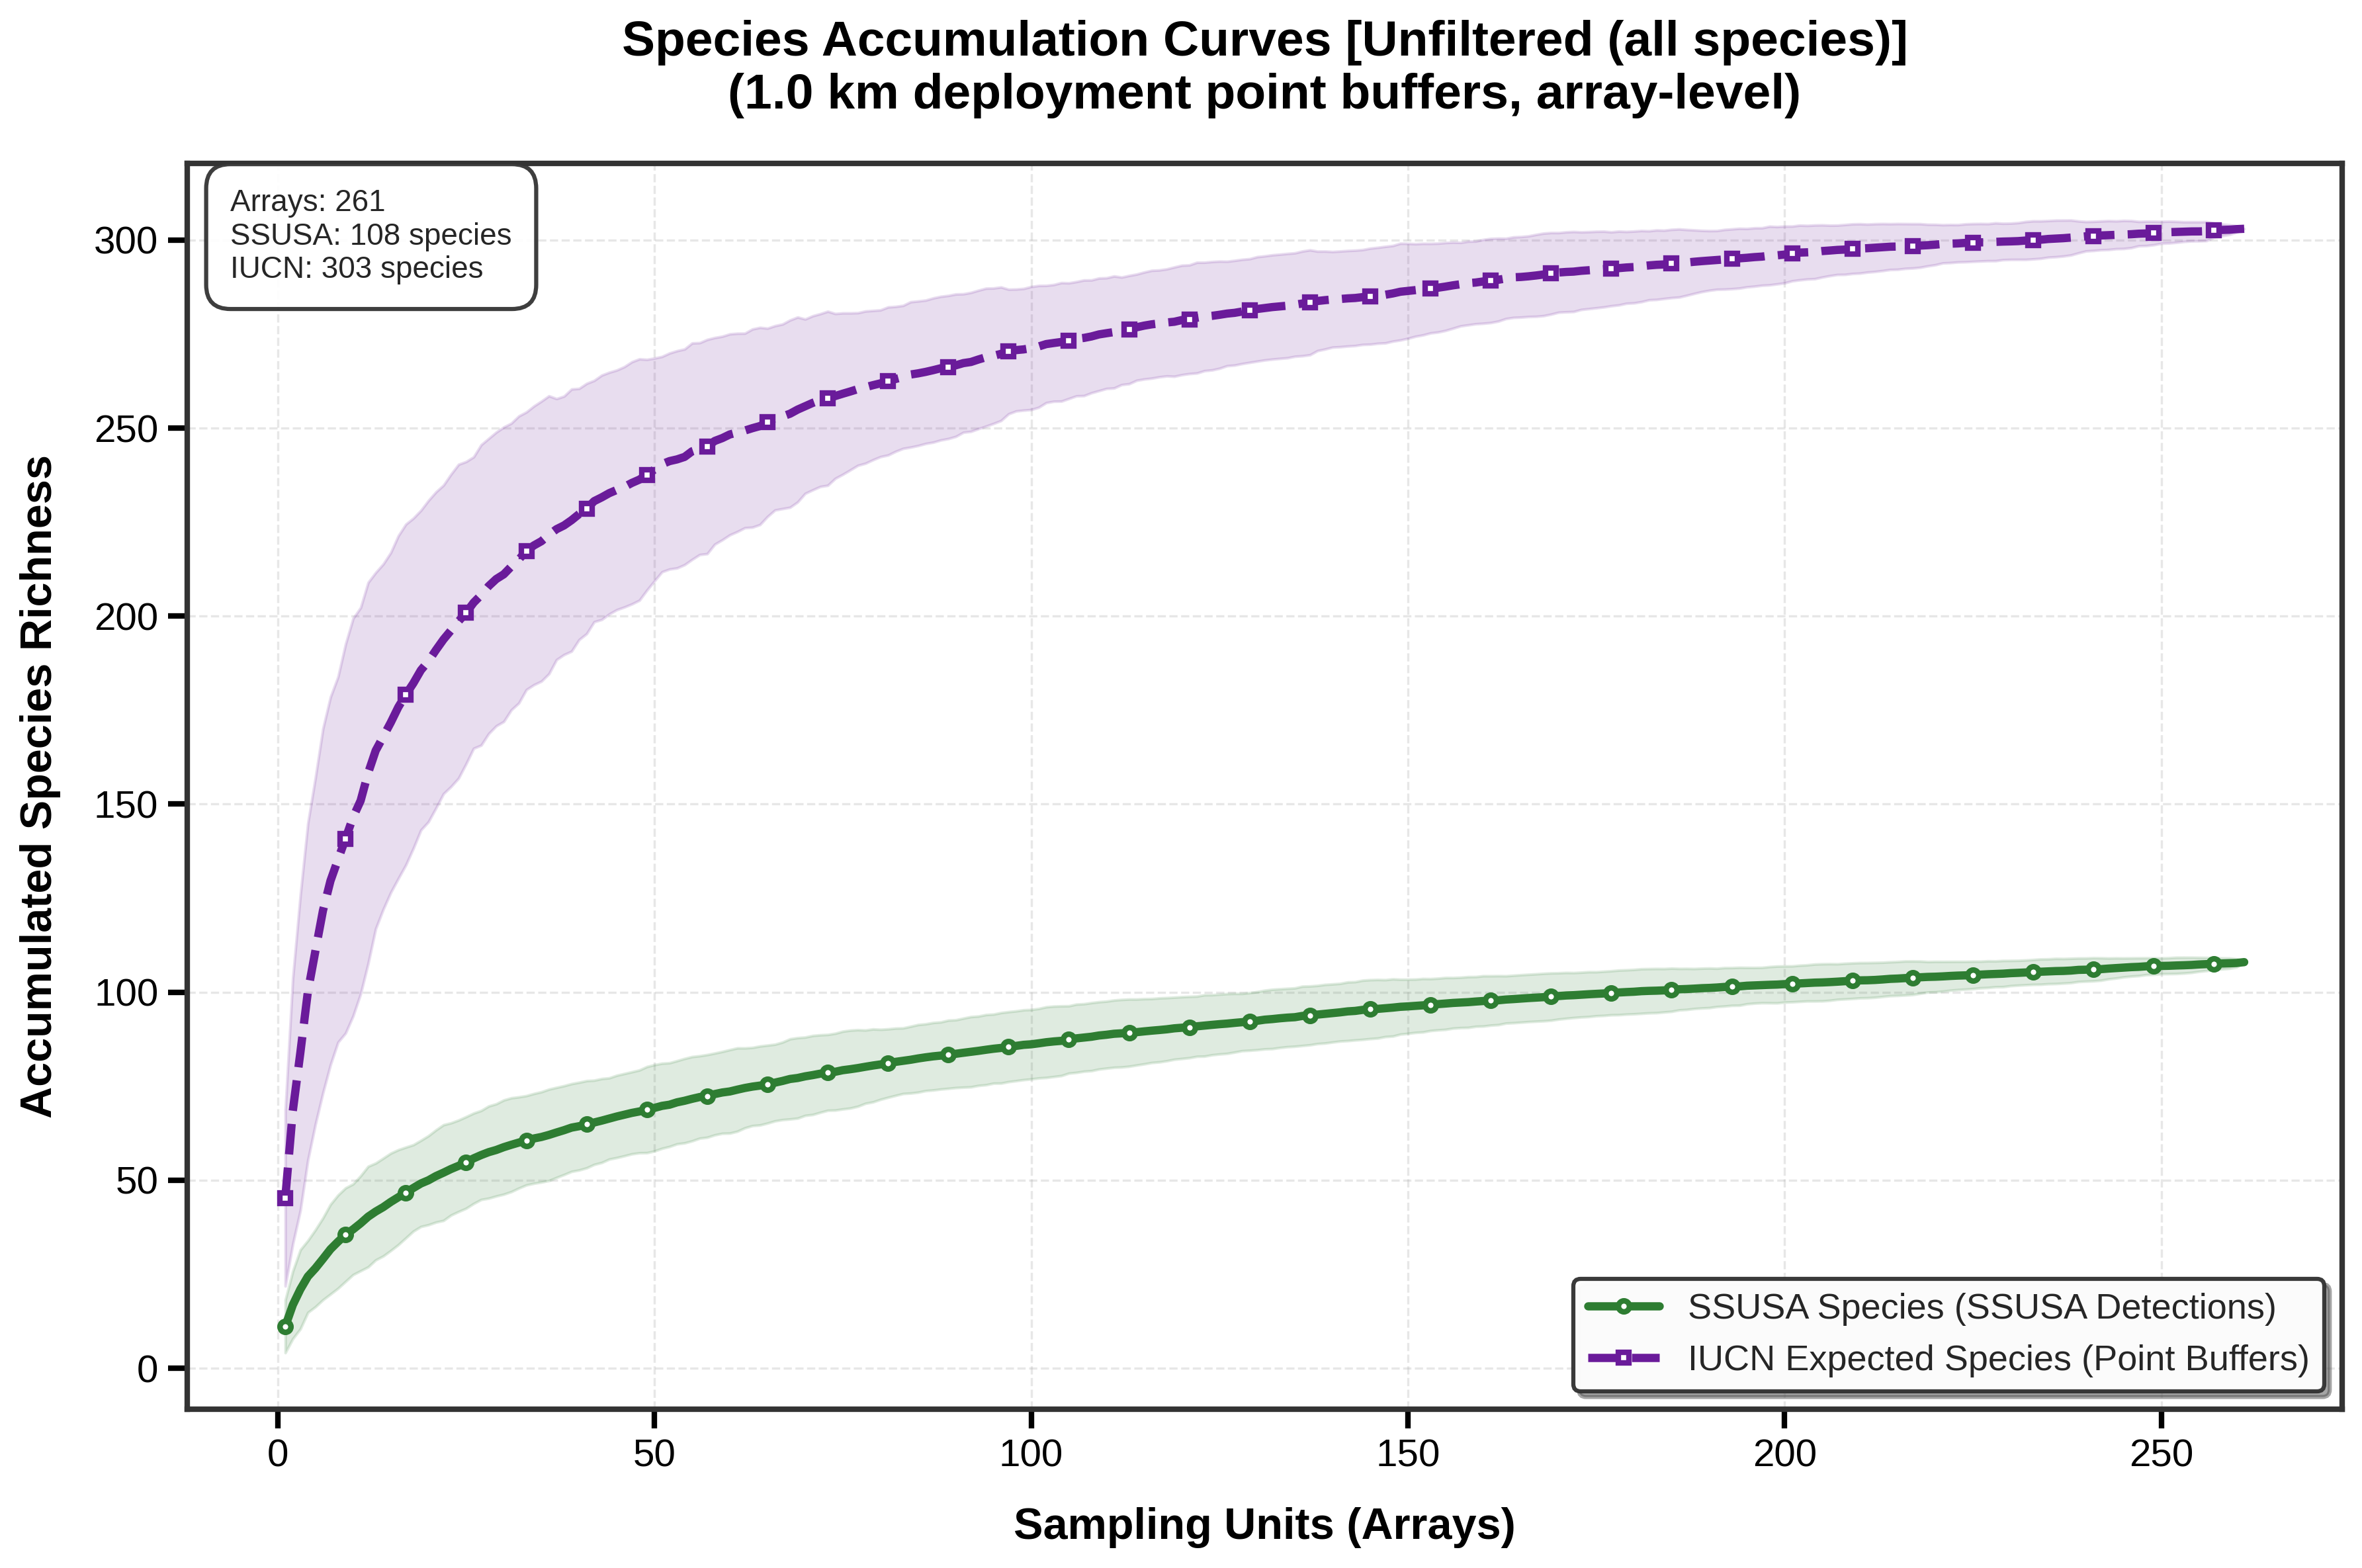


  SSUSA richness : 108
  IUCN richness     : 303
  Detection gap     : 195 species

MASS THRESHOLD: >= 50 g
  Threshold: >= 50 g
    Species with mass data : 244
    Retained by mass       : 119
    Excluded (mass missing): 62
    Removed (below thresh) : 187
    Total eligible         : 119 / 306

  Global comparison (>= 50 g):
    both          : 69
    snapshot_only : 1
    iucn_only     : 49


,species,in_snapshot,in_iucn,category
0,alces alces,True,True,both
1,ammospermophilus harrisii,True,True,both
2,ammospermophilus leucurus,True,True,both
3,antilocapra americana,True,True,both
4,aplodontia rufa,True,True,both
...,...,...,...,...
114,thomomys bulbivorus,False,True,iucn_only
115,thomomys mazama,False,True,iucn_only
116,thomomys monticola,False,True,iucn_only
117,thomomys talpoides,False,True,iucn_only


  Saved to ../data/ssusa/conservative_global_comparison_50g.csv

  SSUSA matrix : 261 arrays x 70 species
  IUCN matrix     : 261 arrays x 118 species


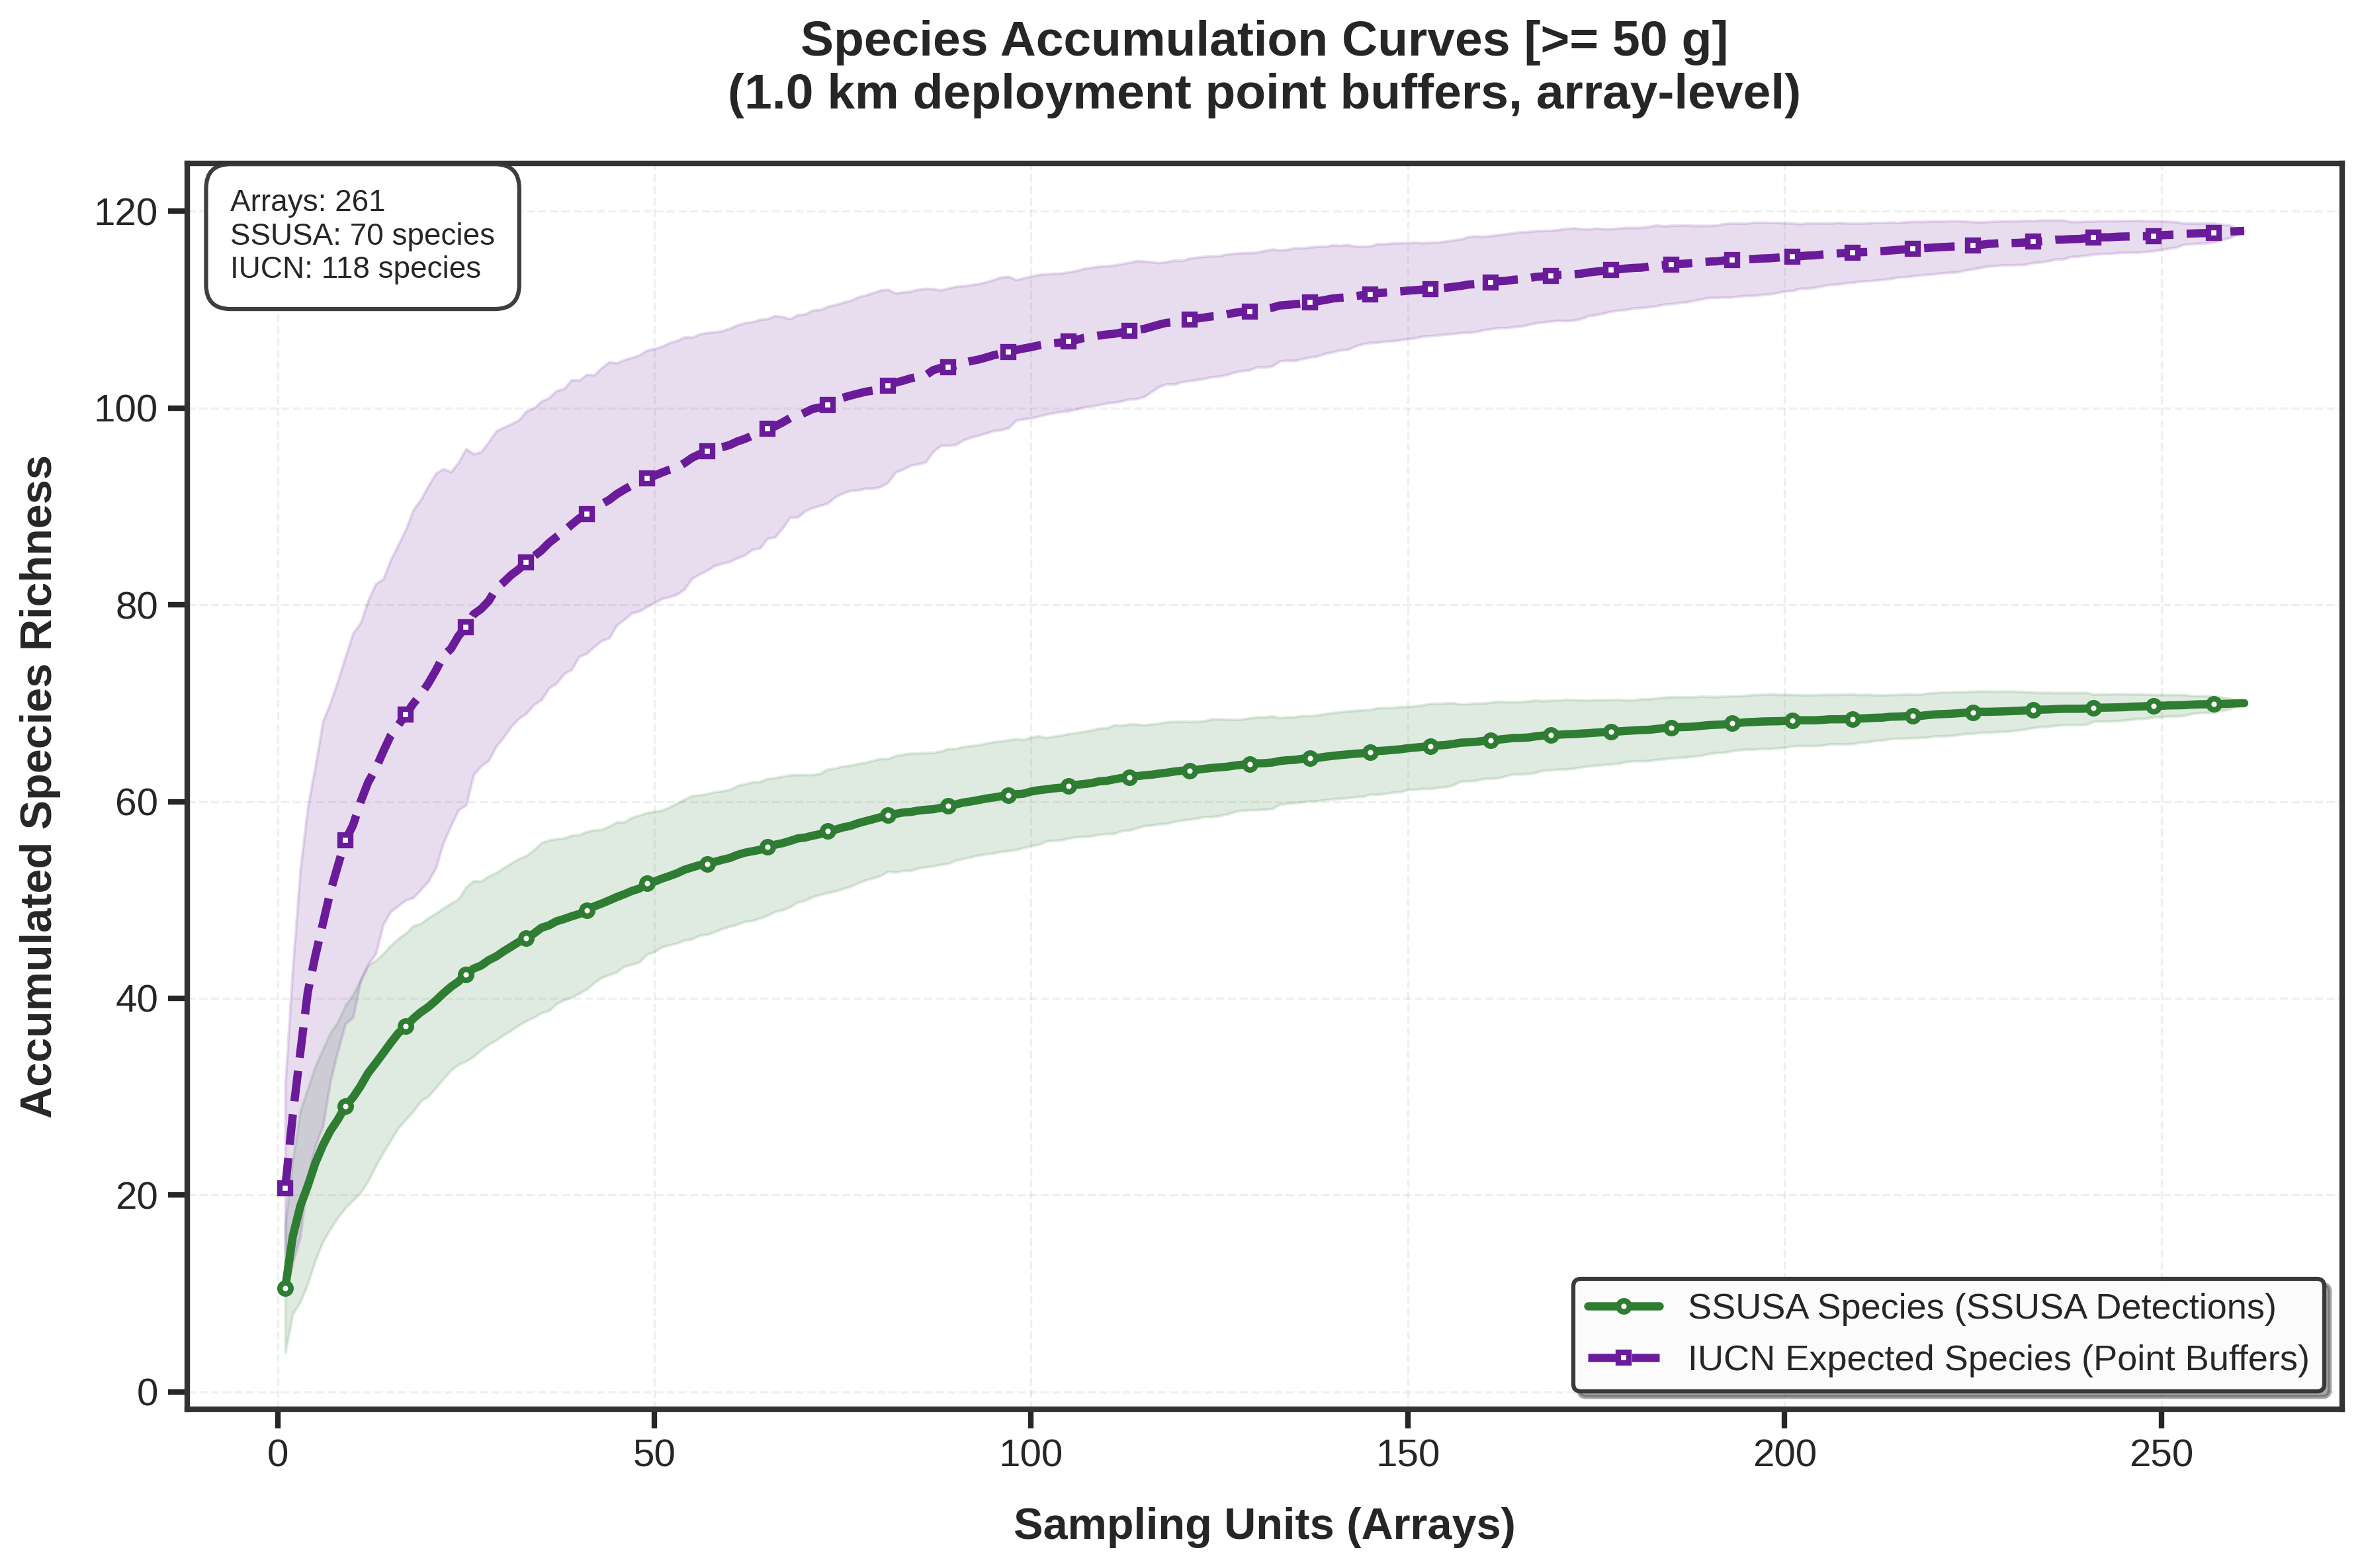


  SSUSA richness : 70
  IUCN richness     : 118
  Detection gap     : 48 species

MASS THRESHOLD: >= 100 g
  Threshold: >= 100 g
    Species with mass data : 244
    Retained by mass       : 99
    Excluded (mass missing): 62
    Removed (below thresh) : 207
    Total eligible         : 99 / 306

  Global comparison (>= 100 g):
    both          : 67
    snapshot_only : 1
    iucn_only     : 31


,species,in_snapshot,in_iucn,category
0,alces alces,True,True,both
1,ammospermophilus harrisii,True,True,both
2,ammospermophilus leucurus,True,True,both
3,antilocapra americana,True,True,both
4,aplodontia rufa,True,True,both
...,...,...,...,...
94,sigmodon ochrognathus,False,True,iucn_only
95,sylvilagus transitionalis,False,True,iucn_only
96,thomomys bulbivorus,False,True,iucn_only
97,thomomys talpoides,False,True,iucn_only


  Saved to ../data/ssusa/conservative_global_comparison_100g.csv

  SSUSA matrix : 261 arrays x 68 species
  IUCN matrix     : 261 arrays x 98 species


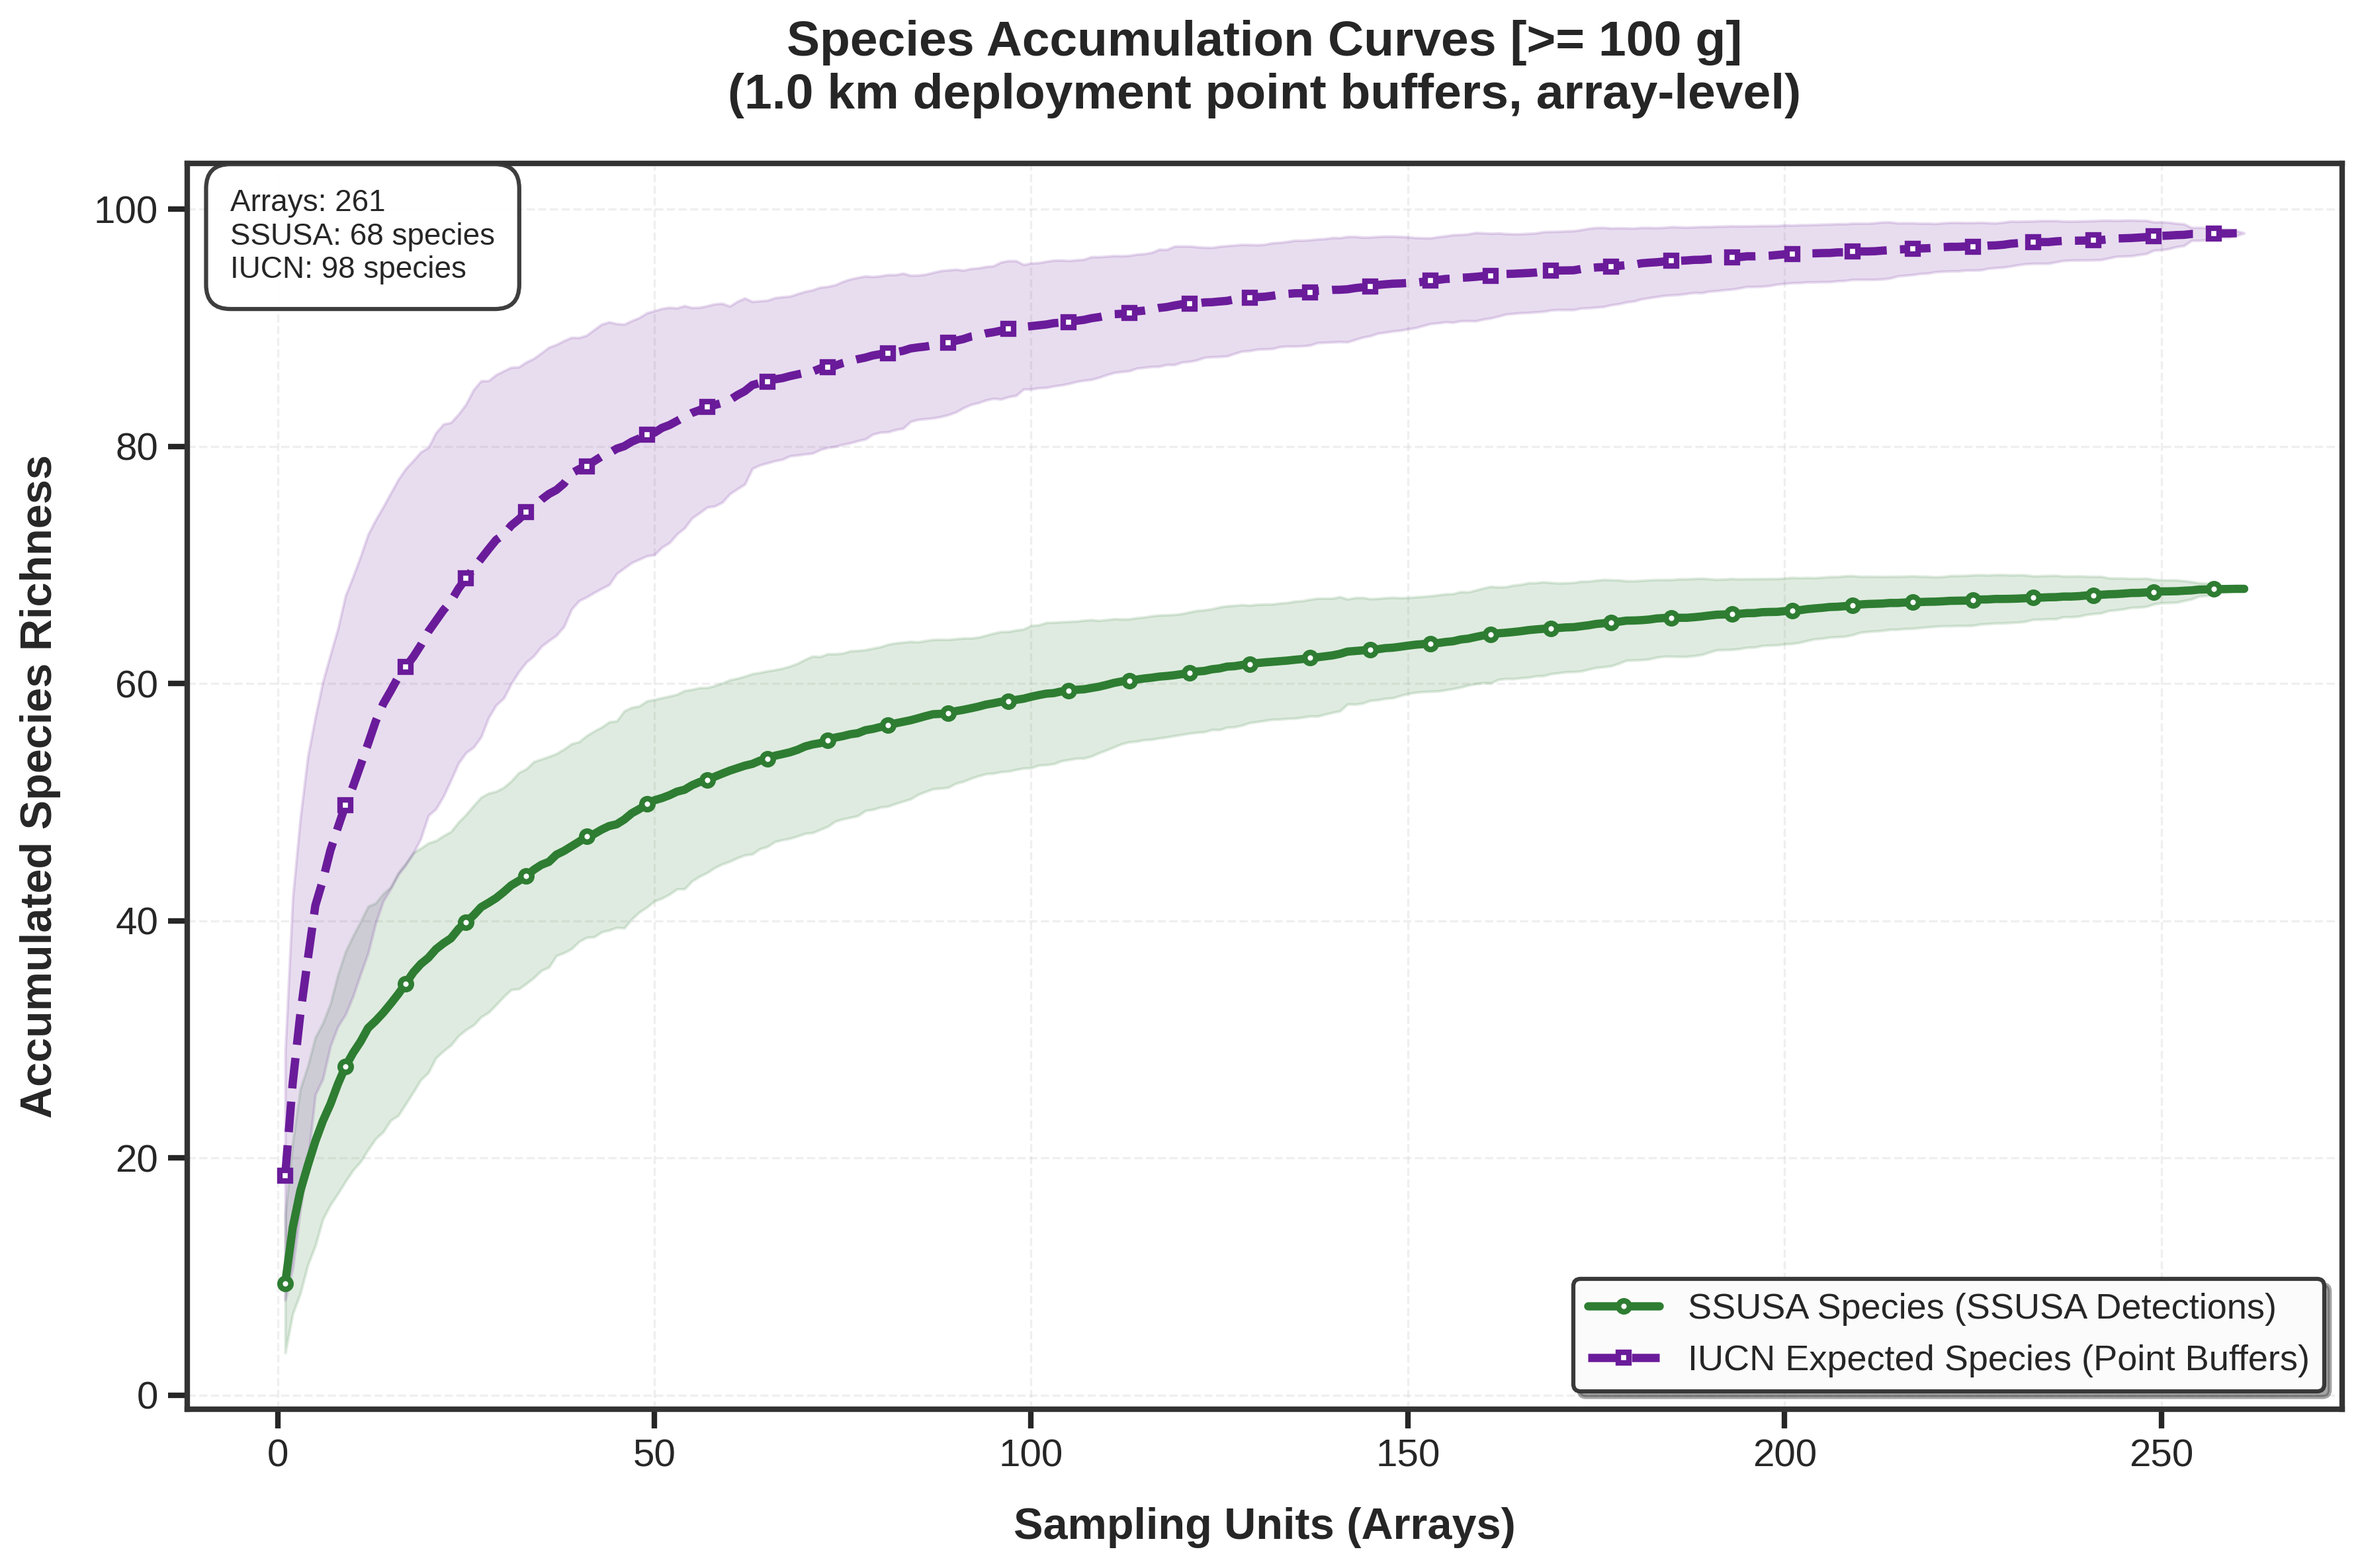


  SSUSA richness : 68
  IUCN richness     : 98
  Detection gap     : 30 species

MASS THRESHOLD: >= 500 g
  Threshold: >= 500 g
    Species with mass data : 244
    Retained by mass       : 58
    Excluded (mass missing): 62
    Removed (below thresh) : 248
    Total eligible         : 58 / 306

  Global comparison (>= 500 g):
    both          : 48
    snapshot_only : 1
    iucn_only     : 9


,species,in_snapshot,in_iucn,category
0,alces alces,True,True,both
1,antilocapra americana,True,True,both
2,aplodontia rufa,True,True,both
3,bassariscus astutus,True,True,both
4,canis latrans,True,True,both
5,canis lupus,True,True,both
6,conepatus leuconotus,True,True,both
7,cynomys leucurus,True,True,both
8,cynomys ludovicianus,True,True,both
9,dasypus novemcinctus,True,True,both


  Saved to ../data/ssusa/conservative_global_comparison_500g.csv

  SSUSA matrix : 261 arrays x 49 species
  IUCN matrix     : 261 arrays x 57 species


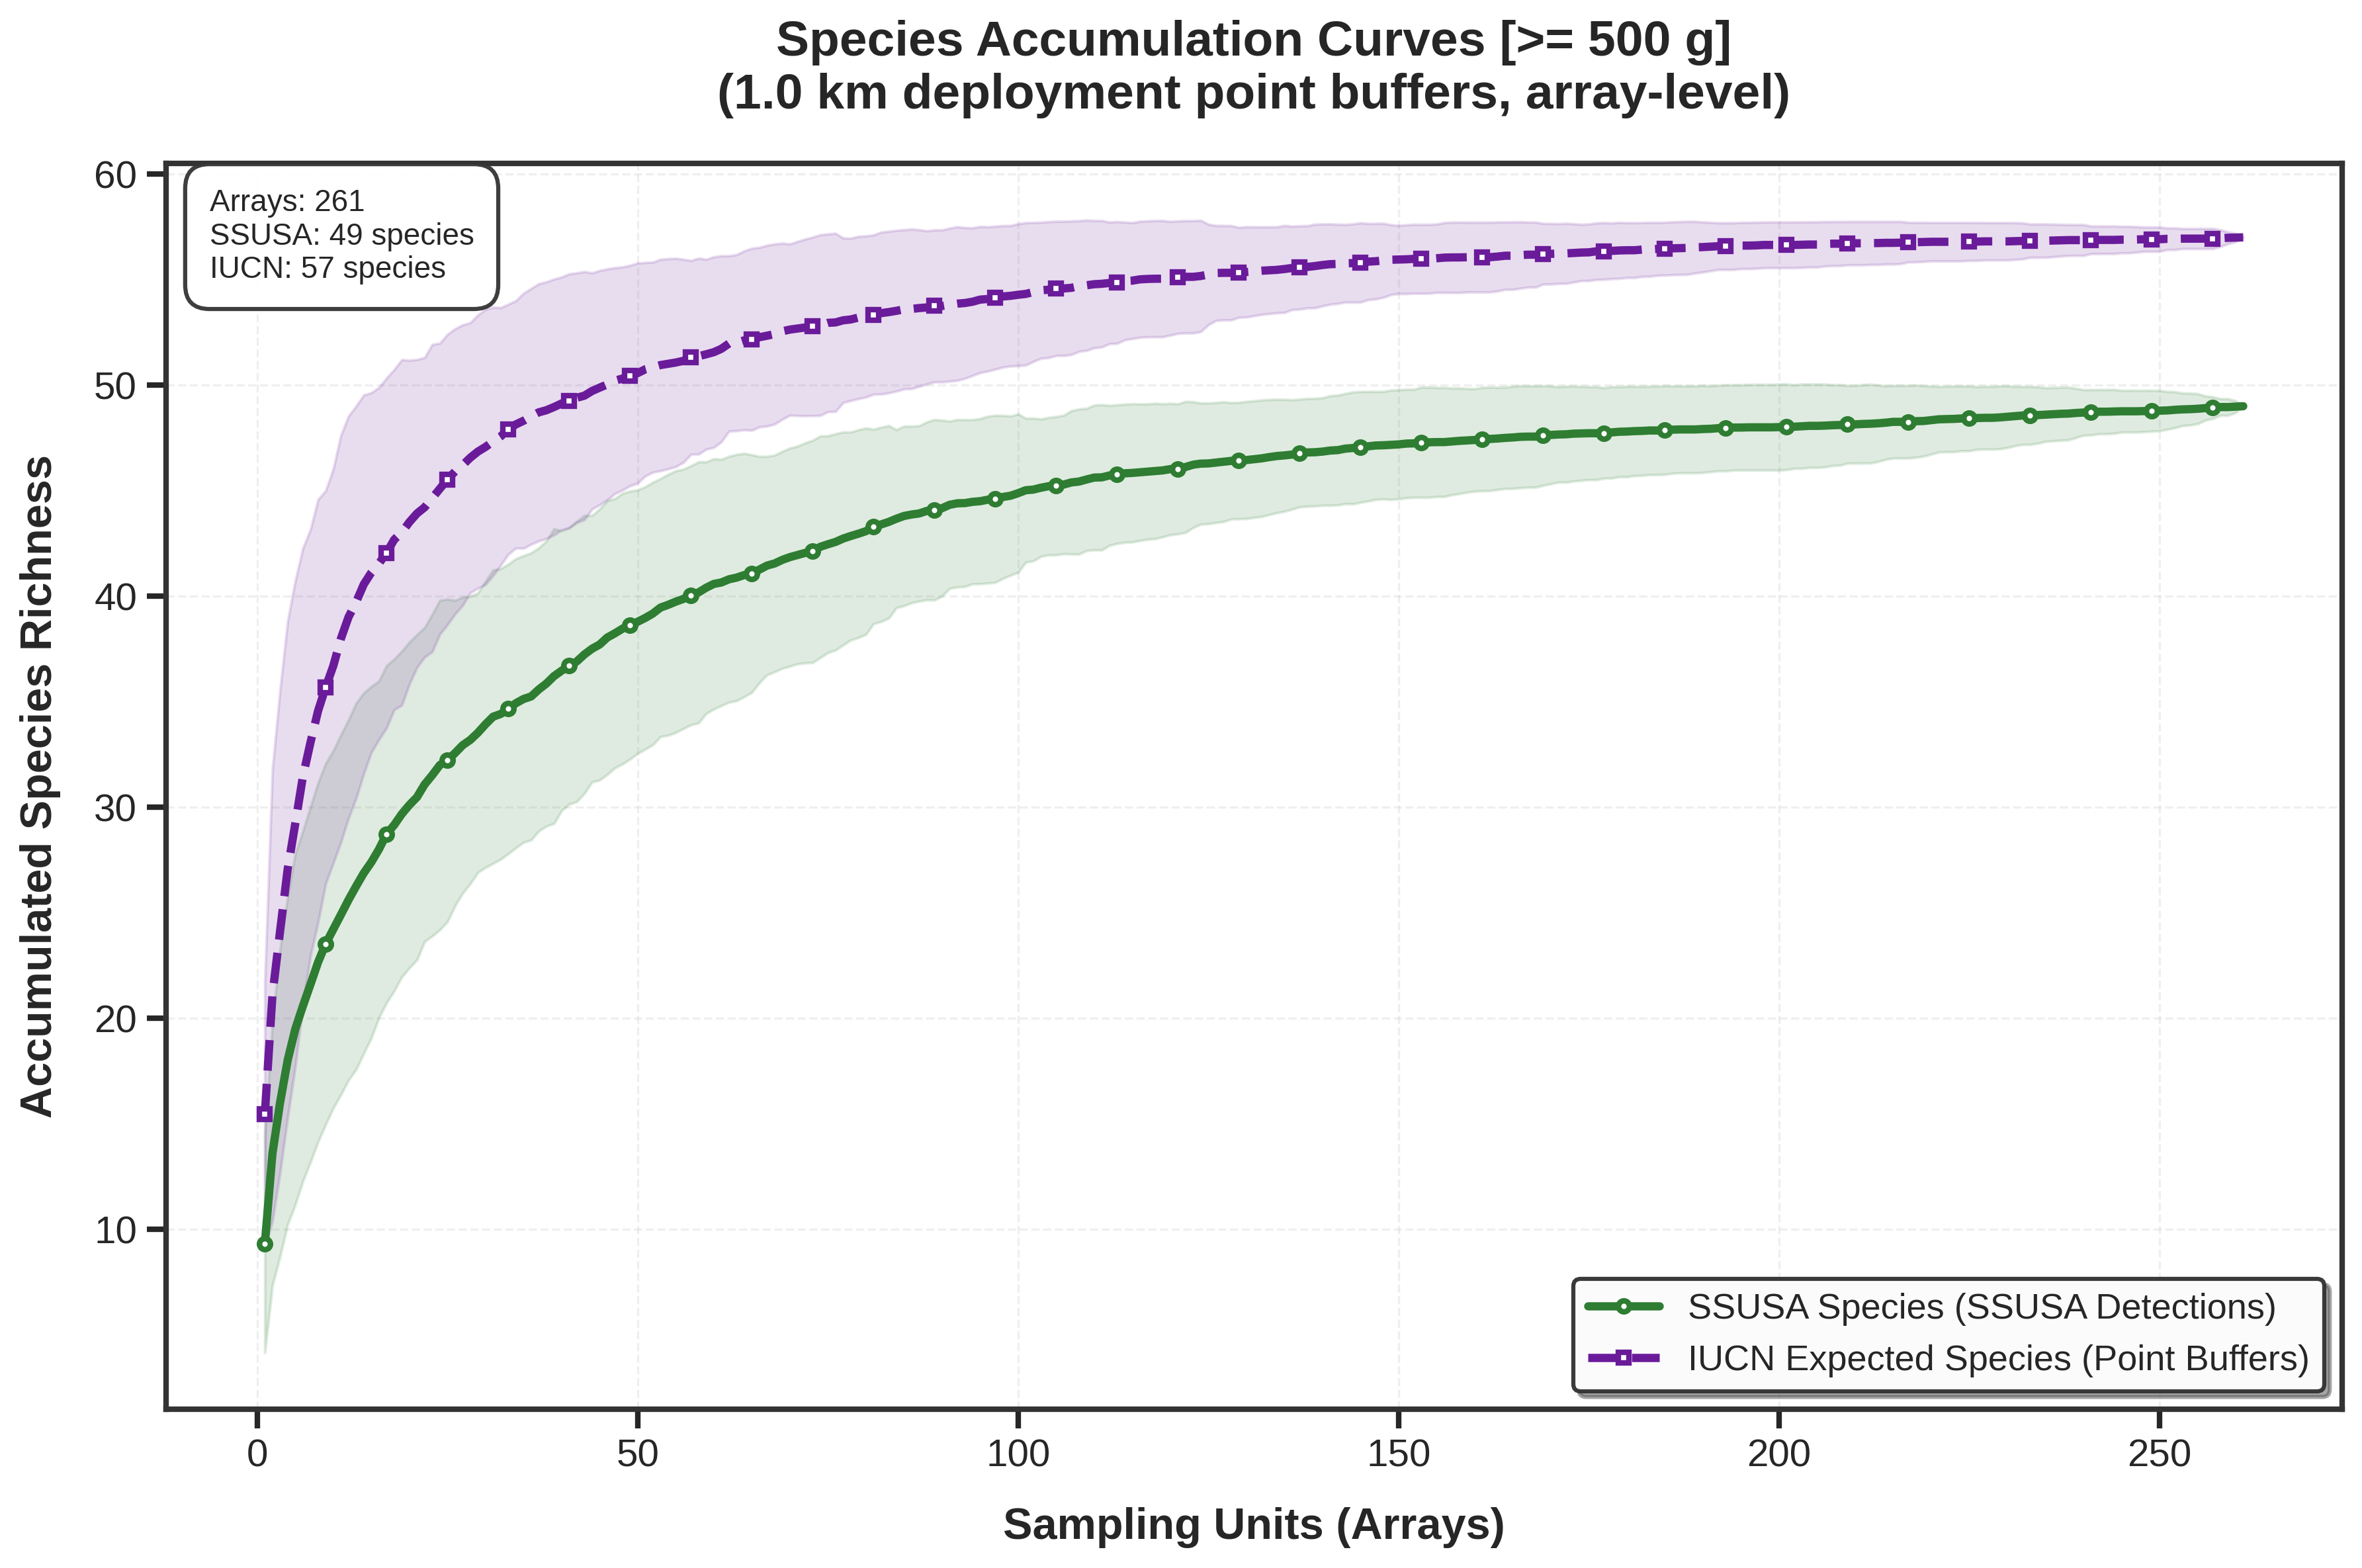


  SSUSA richness : 49
  IUCN richness     : 57
  Detection gap     : 8 species

MASS THRESHOLD: >= 1000 g
  Threshold: >= 1000 g
    Species with mass data : 244
    Retained by mass       : 43
    Excluded (mass missing): 62
    Removed (below thresh) : 263
    Total eligible         : 43 / 306

  Global comparison (>= 1000 g):
    both          : 36
    snapshot_only : 1
    iucn_only     : 6


,species,in_snapshot,in_iucn,category
0,alces alces,True,True,both
1,antilocapra americana,True,True,both
2,bassariscus astutus,True,True,both
3,canis latrans,True,True,both
4,canis lupus,True,True,both
5,conepatus leuconotus,True,True,both
6,dasypus novemcinctus,True,True,both
7,didelphis virginiana,True,True,both
8,erethizon dorsatum,True,True,both
9,gulo gulo,True,True,both


  Saved to ../data/ssusa/conservative_global_comparison_1000g.csv

  SSUSA matrix : 261 arrays x 37 species
  IUCN matrix     : 261 arrays x 42 species


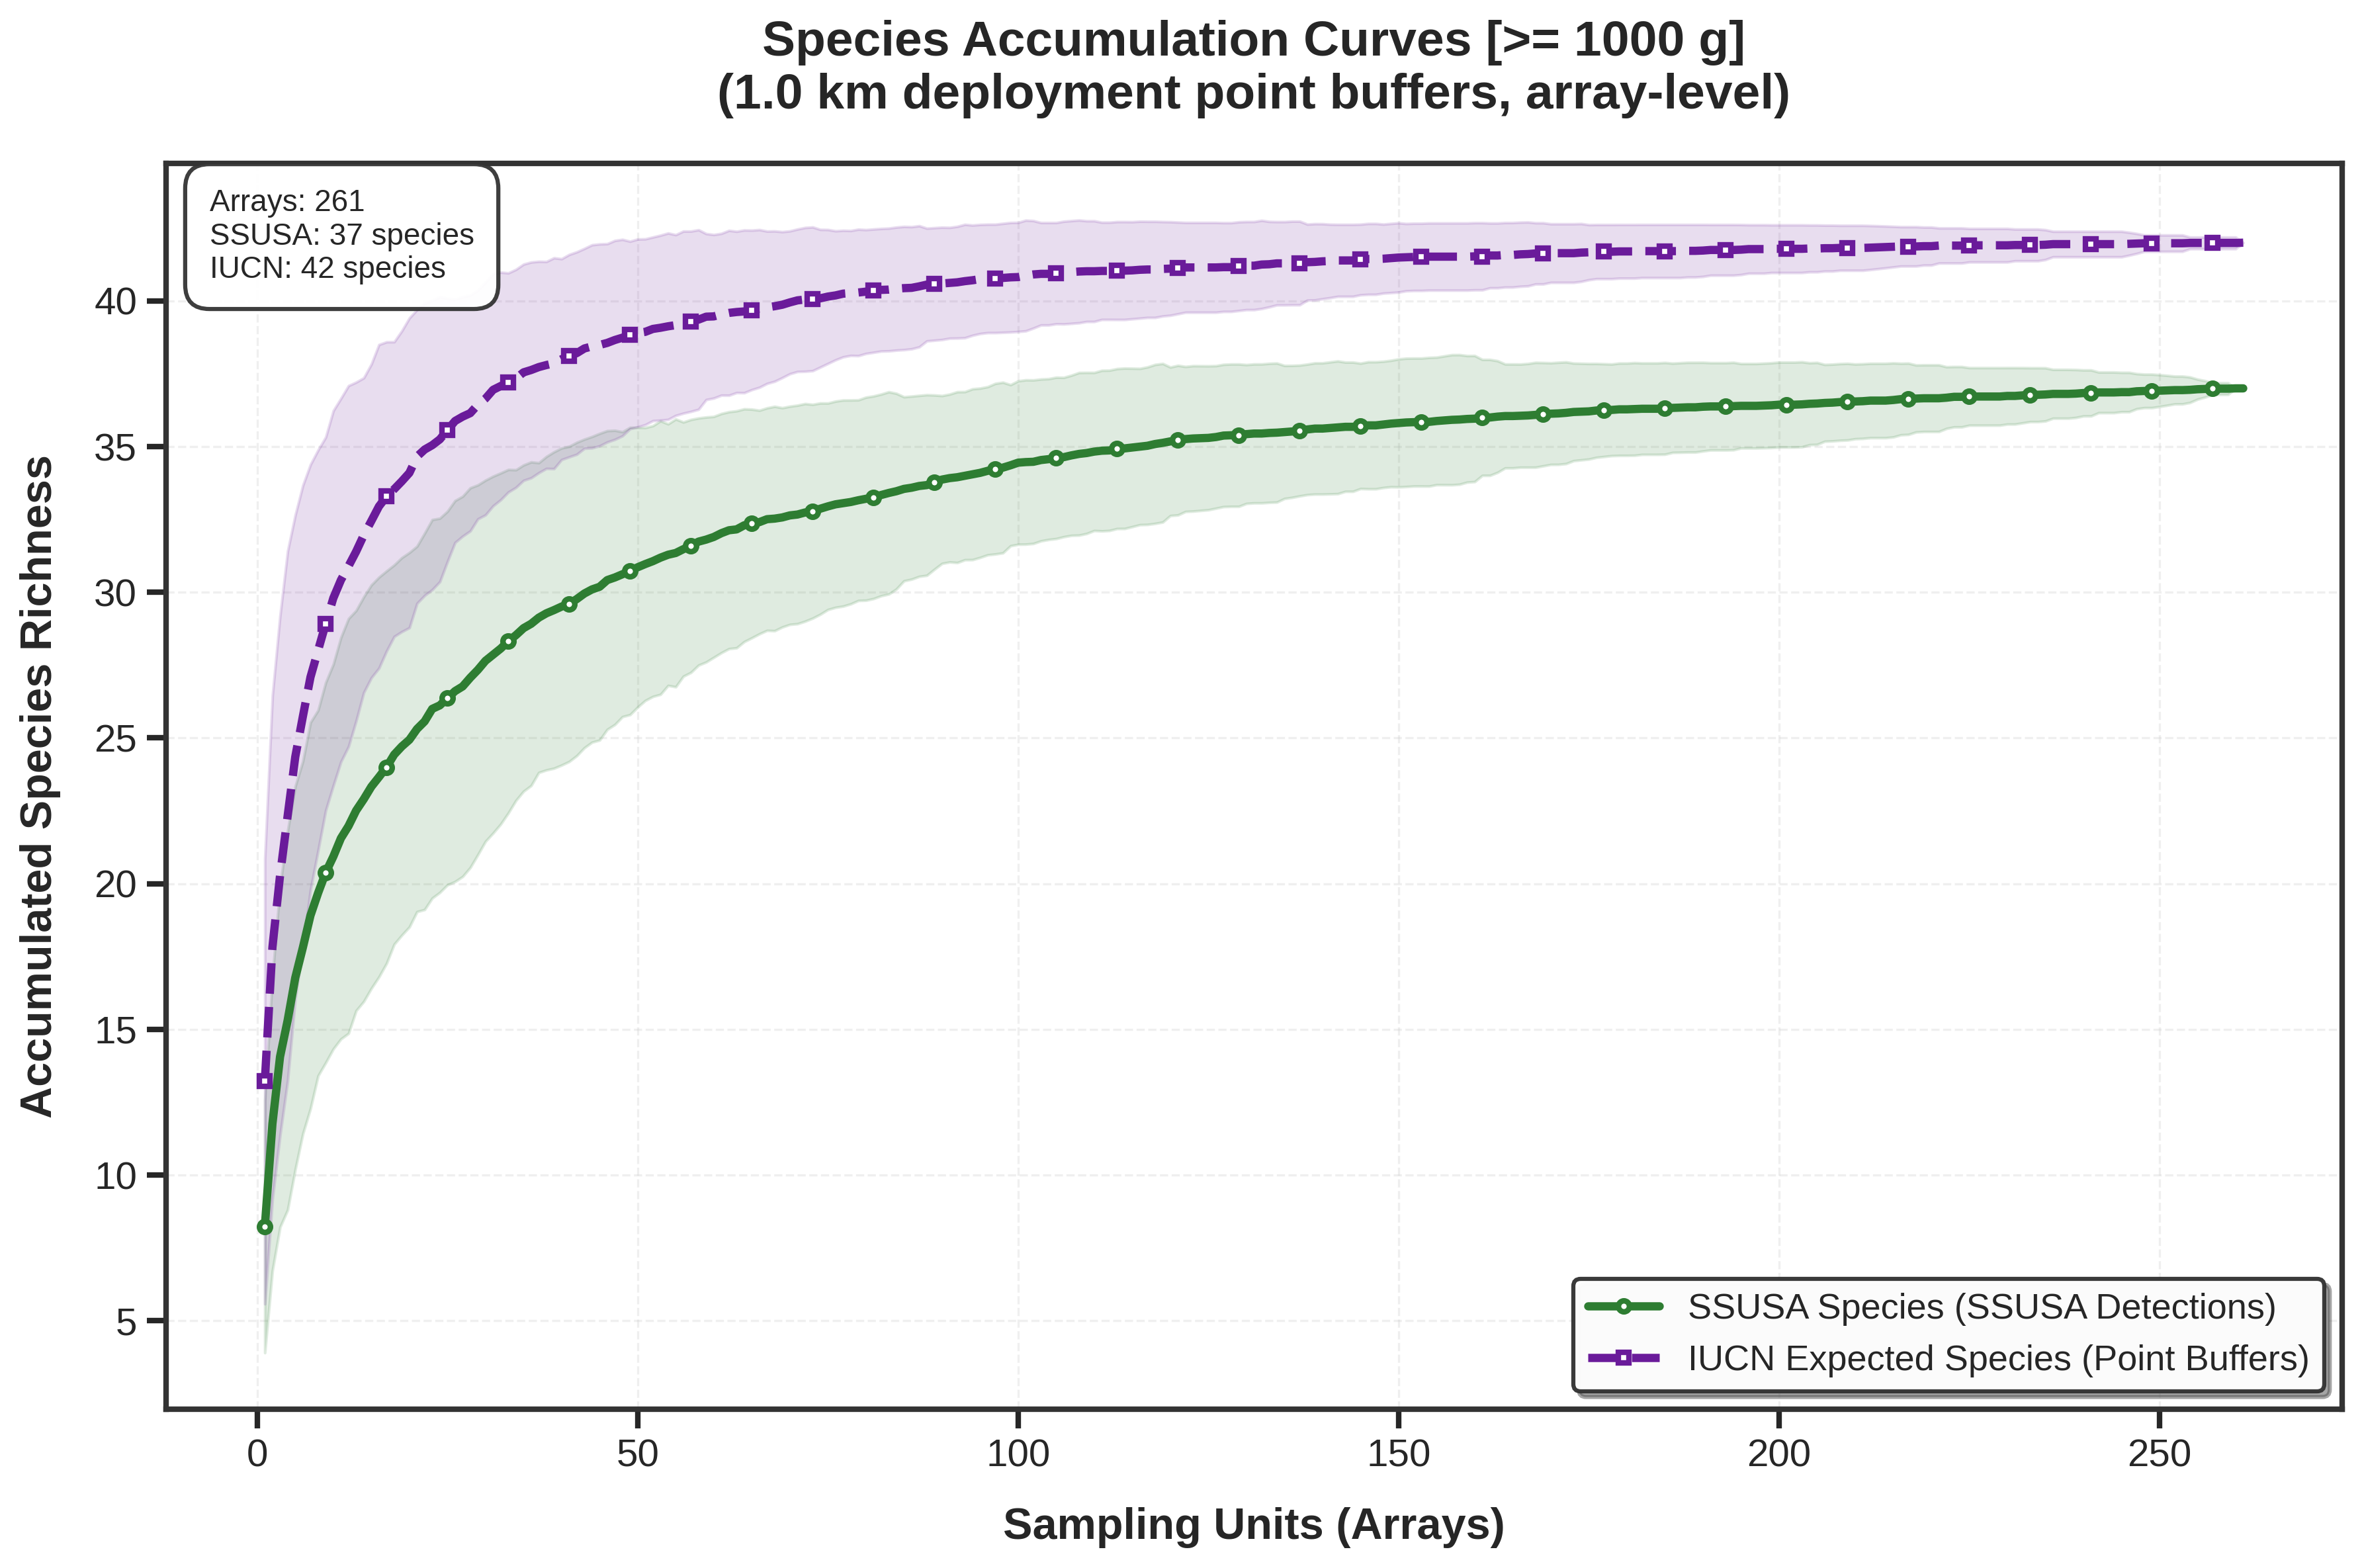


  SSUSA richness : 37
  IUCN richness     : 42
  Detection gap     : 5 species


In [18]:
# ==============================================================================
# Mass-Threshold Analysis Loop
# ==============================================================================
results_summary = []
curve_results = []

all_snapshot_species = set(df_points['Sci_Name'].dropna().unique())
all_iucn_species = set(iucn_in_point_buffers['Sci_Name'].dropna().unique())
all_species = all_snapshot_species | all_iucn_species
n_units = len(all_arrays)

for threshold in mass_thresholds:
    label = threshold_label(threshold)
    print("\n" + "=" * 70)
    print(f"MASS THRESHOLD: {label}")
    print("=" * 70)

    eligible = get_eligible_species(threshold, all_species, pantheria)

    # ---- Filter SSUSA observations first ----
    df_filtered = df_points[df_points['Sci_Name'].isin(eligible)].copy()

    # ---- Filter IUCN deployment-buffer hits with the same rule ----
    iucn_pb_filtered = iucn_in_point_buffers[
        iucn_in_point_buffers['Sci_Name'].isin(eligible)
    ].copy()

    # ------------------------------------------------------------------
    # Global comparison table
    # ------------------------------------------------------------------
    global_joint = build_global_comparison(df_filtered, iucn_pb_filtered, species_col='Sci_Name')
    cat_counts = global_joint['category'].value_counts() if not global_joint.empty else pd.Series(dtype=int)

    print(f"\n  Global comparison ({label}):")
    print(f"    both          : {cat_counts.get('both', 0)}")
    print(f"    snapshot_only : {cat_counts.get('snapshot_only', 0)}")
    print(f"    iucn_only     : {cat_counts.get('iucn_only', 0)}")
    display(global_joint)

    out_csv = os.path.join(save_dir, f"{output_prefix}_{threshold_filesafe(threshold)}.csv")
    global_joint.to_csv(out_csv, index=False)
    print(f"  Saved to {out_csv}")

    # ------------------------------------------------------------------
    # Array-level presence/absence matrices
    # ------------------------------------------------------------------
    mat_obs = get_species_matrix(
        df_filtered,
        unit_col=array_col,
        species_col='Sci_Name',
        all_units=all_arrays,
    )
    mat_iucn = get_species_matrix(
        iucn_pb_filtered,
        unit_col=array_col,
        species_col='Sci_Name',
        all_units=all_arrays,
    )

    n_sp_obs = mat_obs.shape[1]
    n_sp_iucn = mat_iucn.shape[1]

    print(f"\n  SSUSA matrix : {n_units} arrays x {n_sp_obs} species")
    print(f"  IUCN matrix     : {n_units} arrays x {n_sp_iucn} species")

    summary_row = {
        'Threshold': label,
        'Arrays': n_units,
        'Eligible Species': len(eligible),
        'SSUSA Species': n_sp_obs,
        'IUCN Species': n_sp_iucn,
        'Both': int(cat_counts.get('both', 0)),
        'Snapshot Only': int(cat_counts.get('snapshot_only', 0)),
        'IUCN Only': int(cat_counts.get('iucn_only', 0)),
        'Detection Gap': int(n_sp_iucn - n_sp_obs),
    }

    # ------------------------------------------------------------------
    # Species Accumulation Curves
    # ------------------------------------------------------------------
    if n_units < 2 or n_sp_obs < 1 or n_sp_iucn < 1:
        print('  ** Not enough data for SAC -- skipping this threshold figure.')
        results_summary.append(summary_row)
        continue

    acc_obs = species_accumulation(mat_obs, method='random', permutations=sac_permutations)
    acc_iucn = species_accumulation(mat_iucn, method='random', permutations=sac_permutations)

    plot_threshold_sac(
        acc_obs,
        acc_iucn,
        n_units=n_units,
        n_sp_obs=n_sp_obs,
        n_sp_iucn=n_sp_iucn,
        label=label,
        buffer_km=point_buffer_km,
    )

    curve_results.append({
        'threshold': threshold,
        'label': label,
        'n_units': n_units,
        'acc_obs': acc_obs,
        'acc_iucn': acc_iucn,
    })
    results_summary.append(summary_row)

COMBINED THRESHOLD OVERLAY


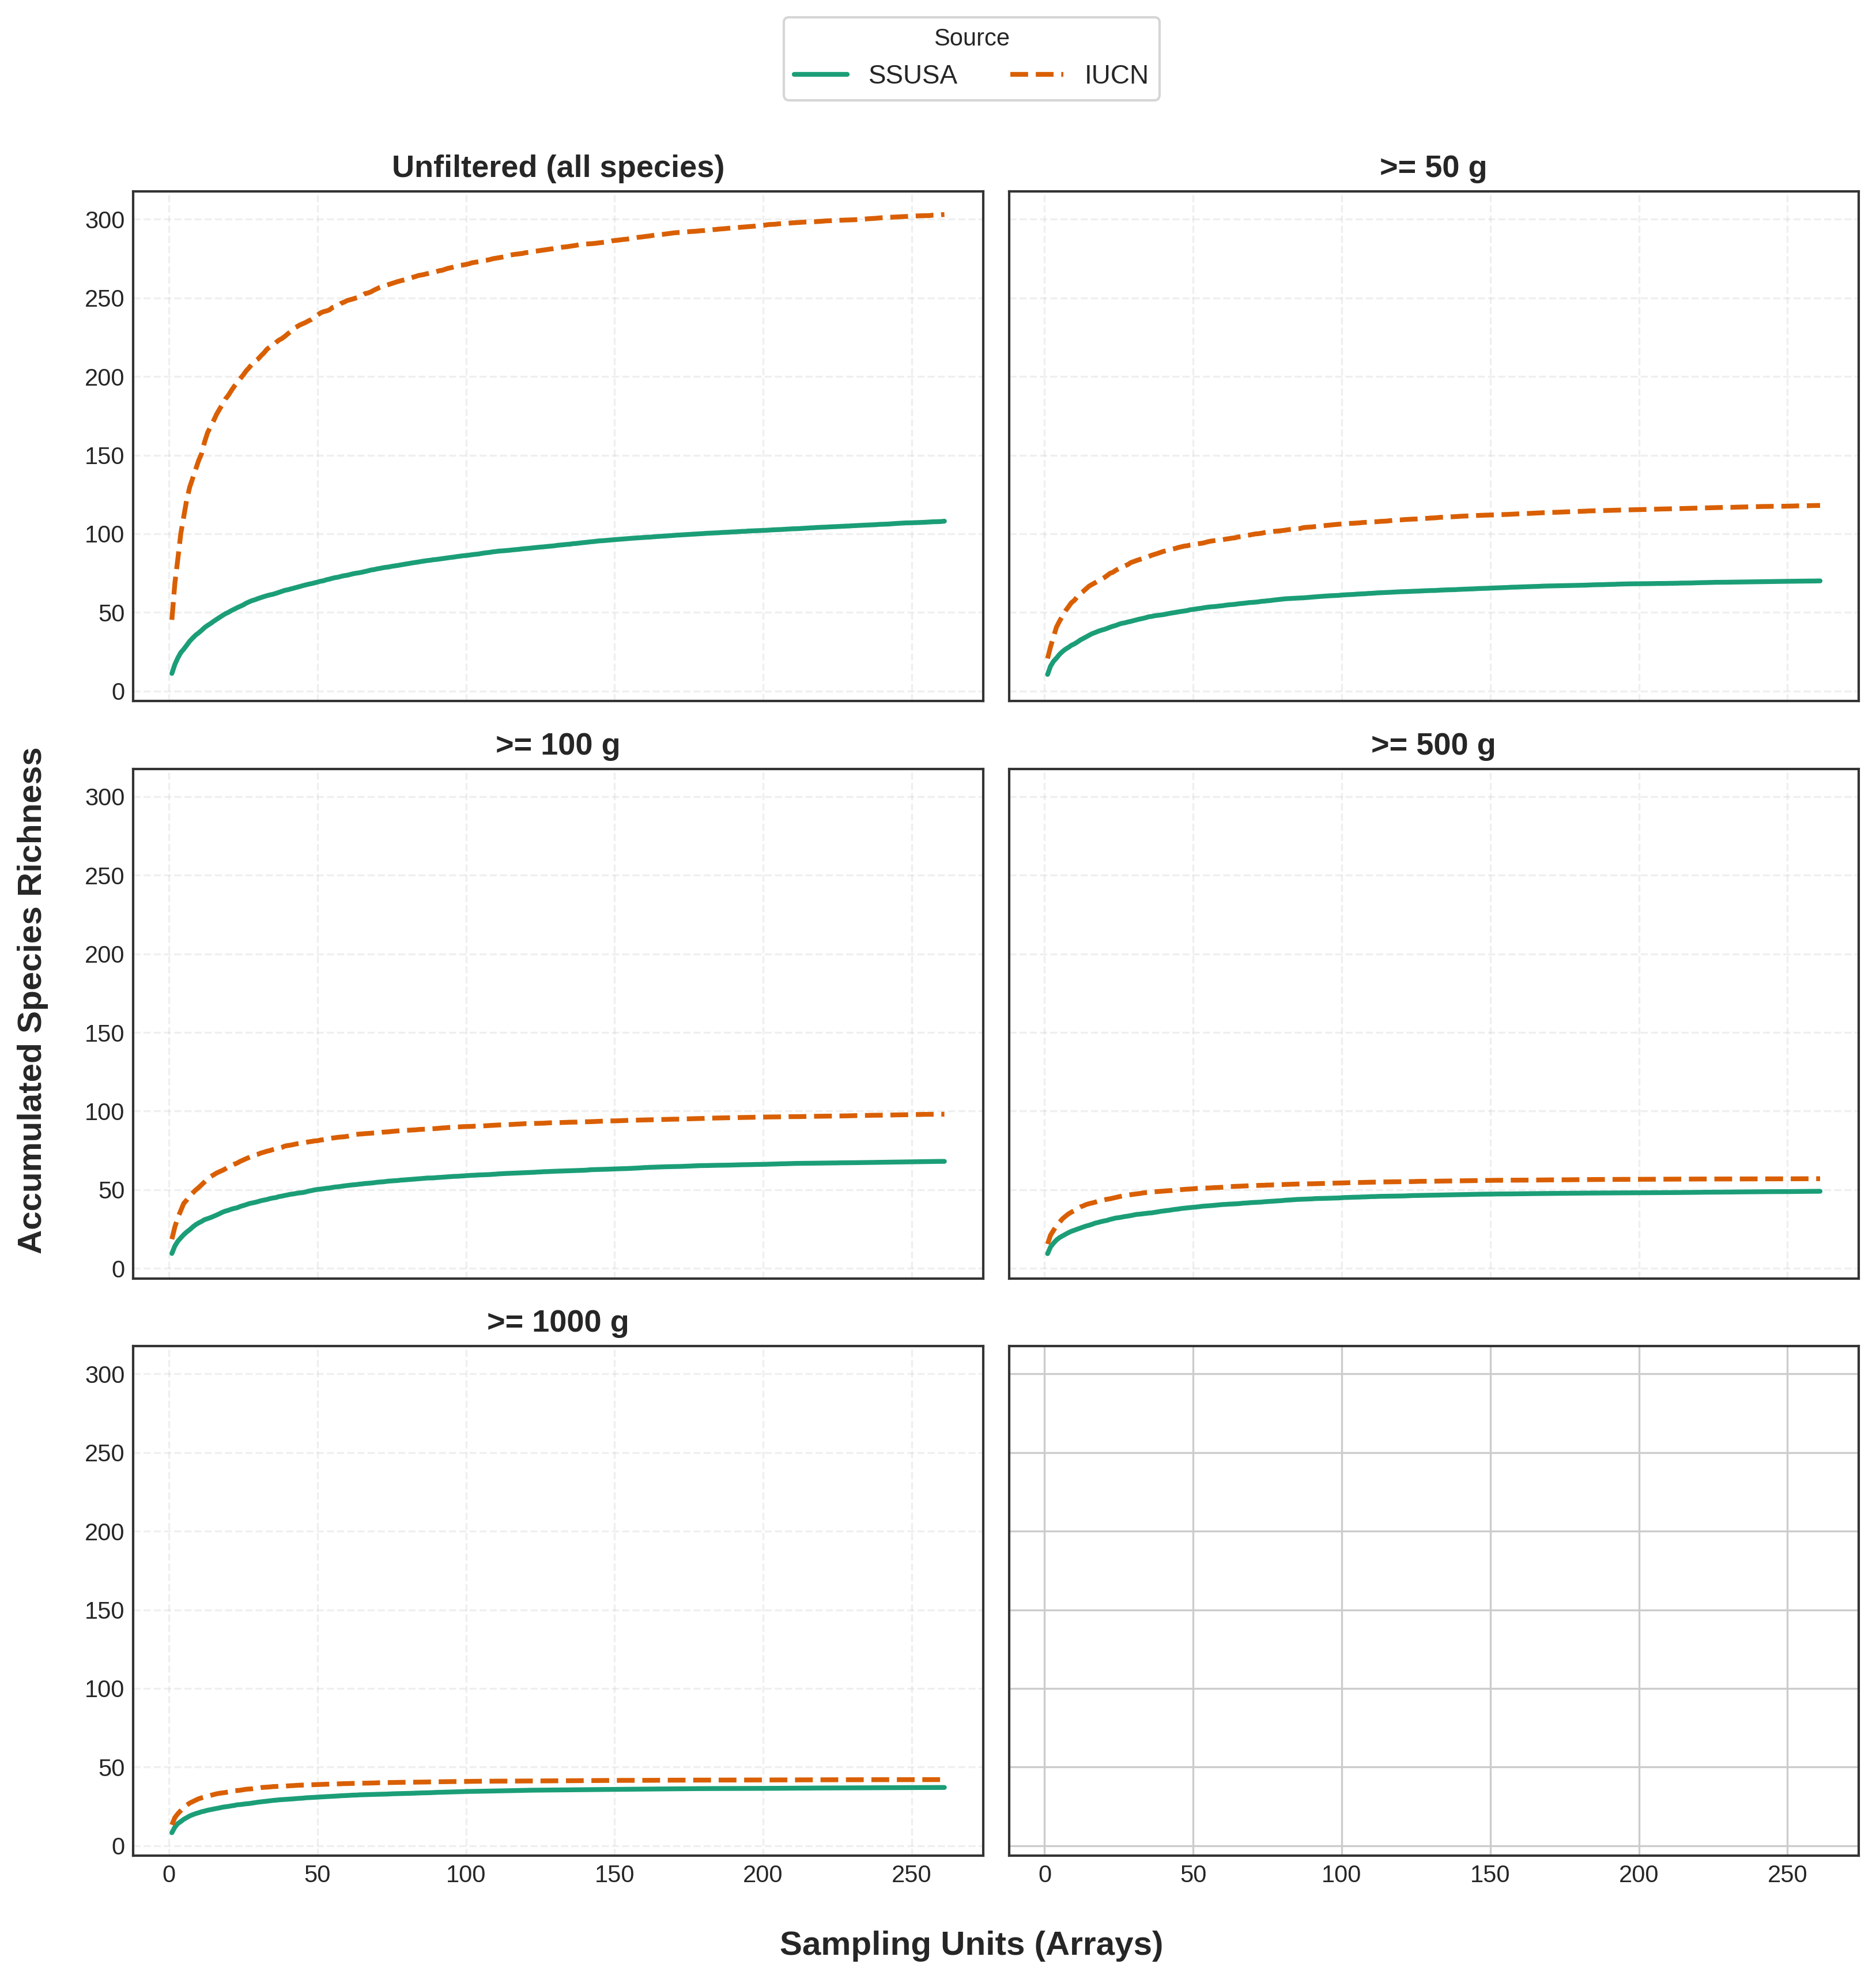

CROSS-THRESHOLD SUMMARY


,Threshold,Arrays,Eligible Species,SSUSA Species,IUCN Species,Both,Snapshot Only,IUCN Only,Detection Gap
0,Unfiltered (all species),261,306,108,303,105,3,198,195
1,>= 50 g,261,119,70,118,69,1,49,48
2,>= 100 g,261,99,68,98,67,1,31,30
3,>= 500 g,261,58,49,57,48,1,9,8
4,>= 1000 g,261,43,37,42,36,1,6,5


In [19]:
# ==============================================================================
# Combined Threshold Overlay + Cross-Threshold Summary
# ==============================================================================
print('=' * 80)
print('COMBINED THRESHOLD OVERLAY')
print('=' * 80)
if curve_results:
    plot_threshold_overlay(curve_results, point_buffer_km)
else:
    print('No SAC curves were available for the combined overlay plot.')

summary_df = pd.DataFrame(results_summary)
print('=' * 80)
print('CROSS-THRESHOLD SUMMARY')
print('=' * 80)
display(summary_df)

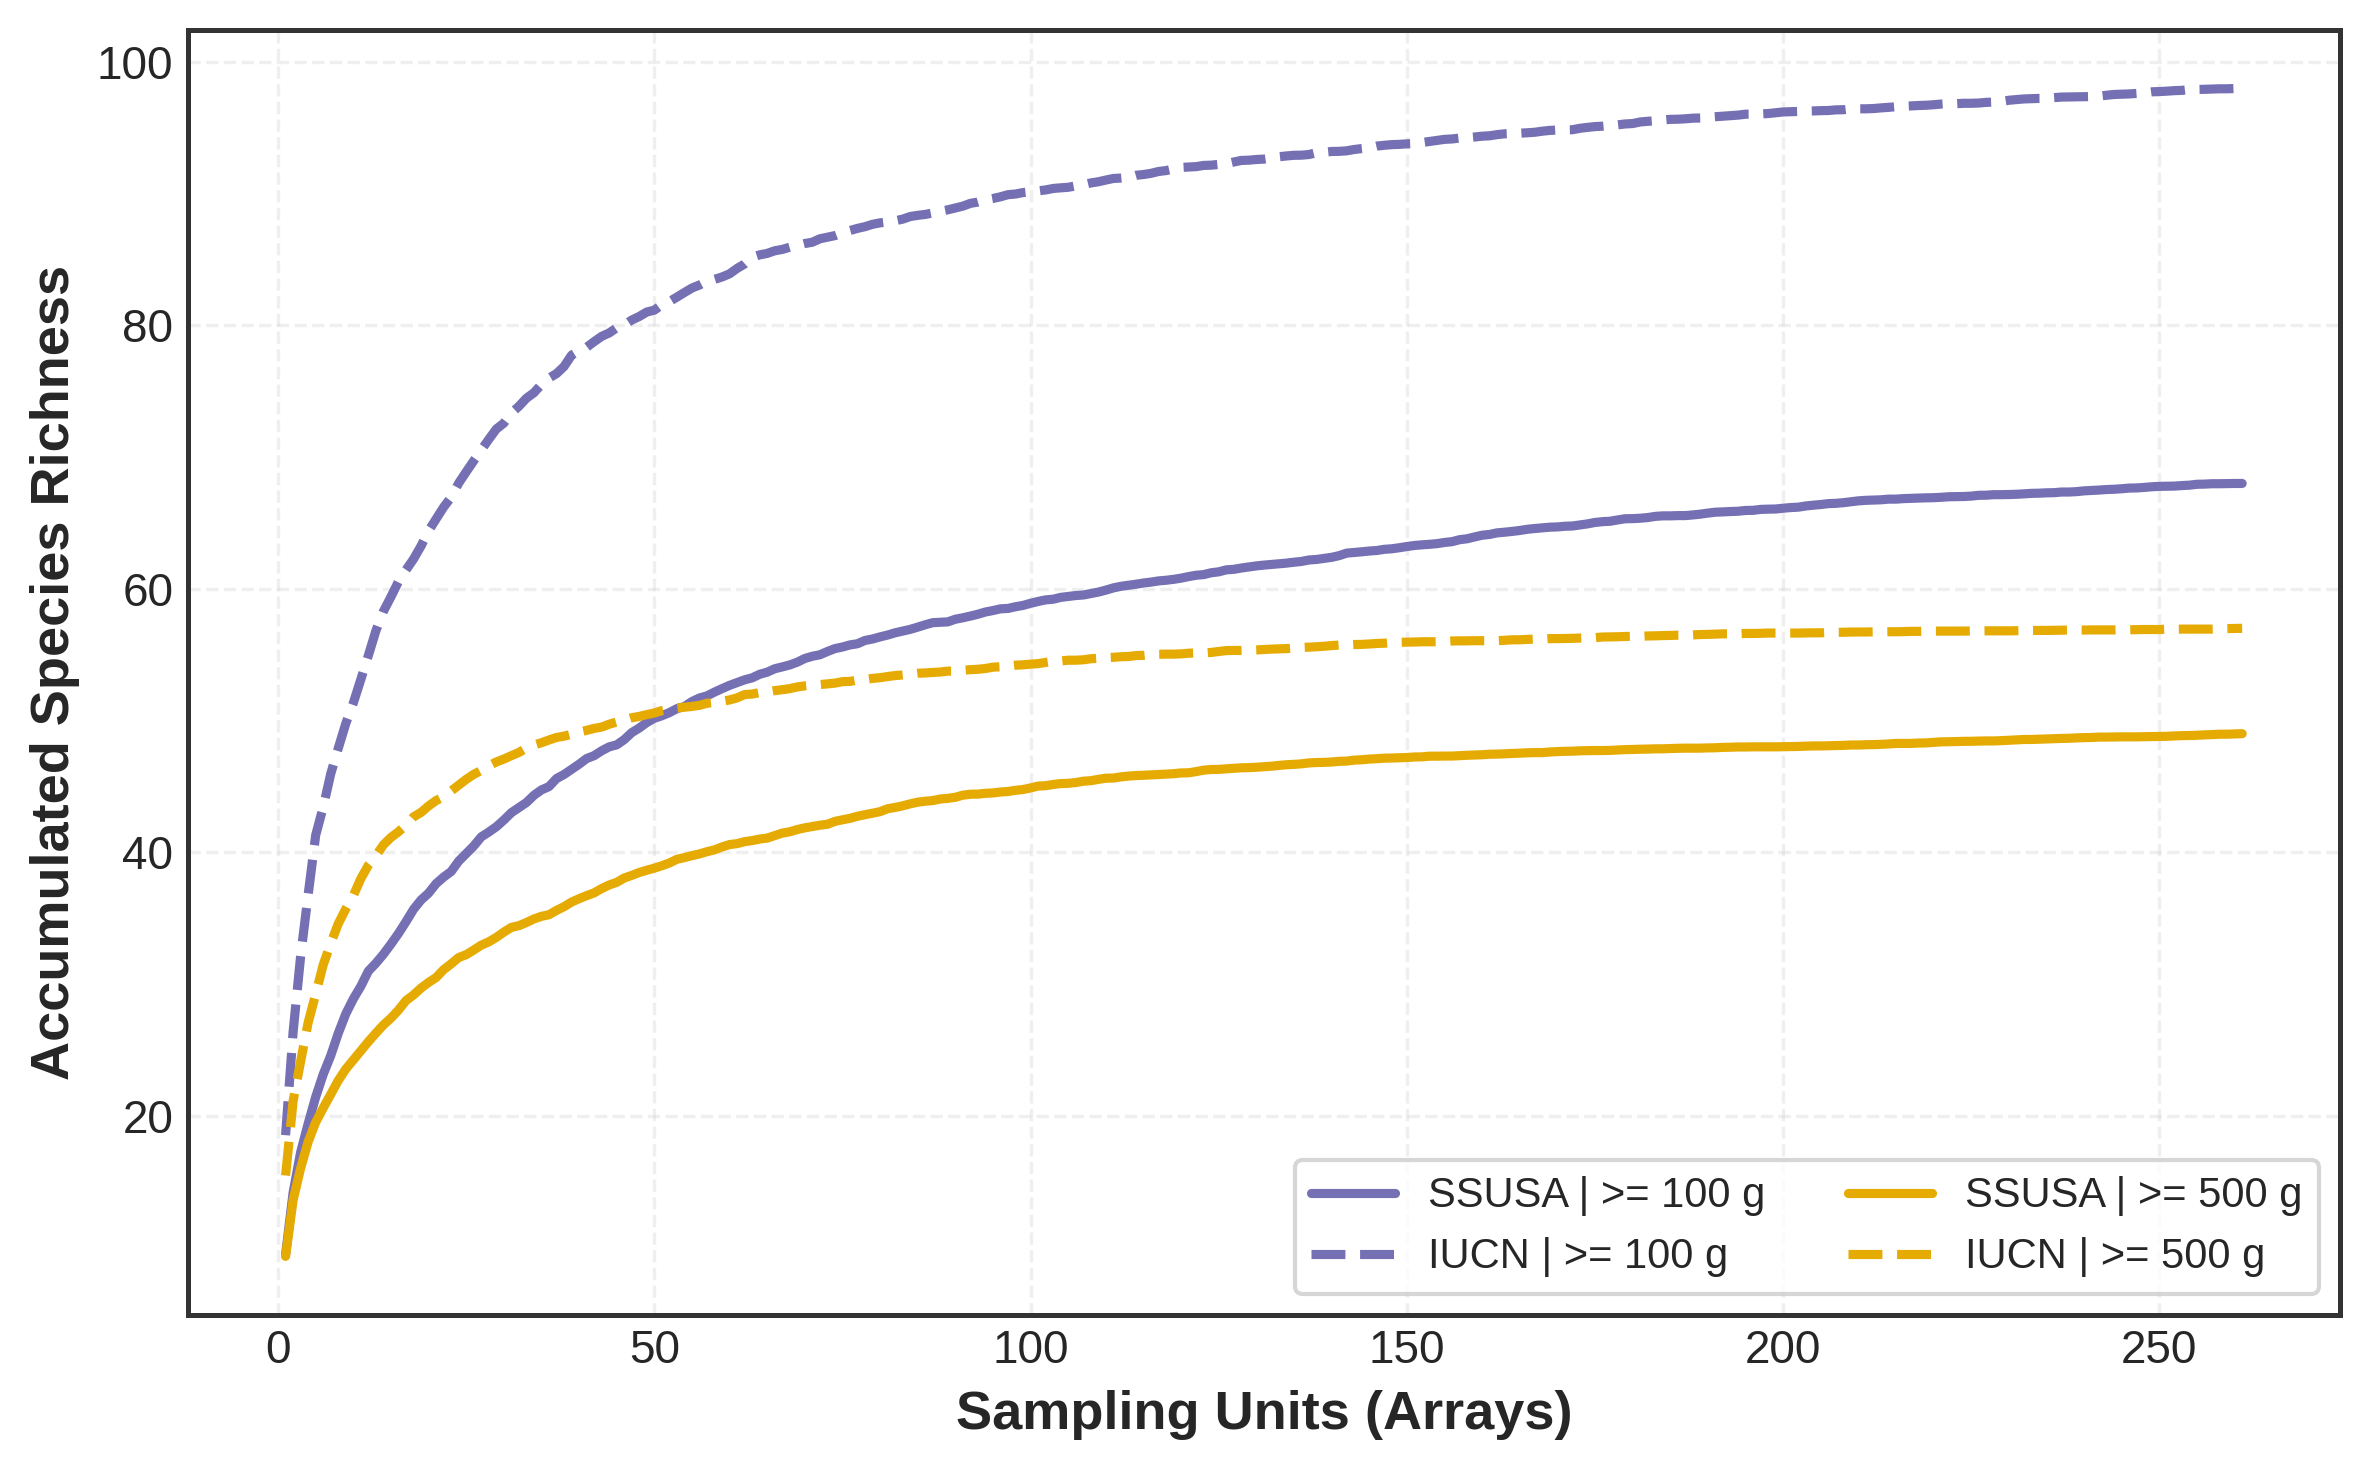

In [20]:
# ==============================================================================
# Direct Comparison: 100 g vs 500 g (primary focus)
# ==============================================================================
if curve_results:
    plot_threshold_pair_comparison(curve_results, point_buffer_km,
                                   labels_to_compare=(">= 100 g", ">= 500 g"))
else:
    print('No SAC curves were available for the comparison plot.')

# Cross-Threshold Species Comparison

## 100 g vs 500 g (Primary Focus)
Which species are retained at >= 100 g but excluded at >= 500 g?

In [21]:
# ---------------------------------------------------------
# 100 g vs 500 g — species present at >=100g but not >=500g
# ---------------------------------------------------------
comp100 = pd.read_csv(os.path.join(save_dir, f"{output_prefix}_100g.csv"))
comp500 = pd.read_csv(os.path.join(save_dir, f"{output_prefix}_500g.csv"))

# SSUSA species sets at each threshold
ssusa100 = set(comp100.loc[comp100["in_snapshot"], "species"].str.lower())
ssusa500 = set(comp500.loc[comp500["in_snapshot"], "species"].str.lower())

# Species present at >=100g but not >=500g
extra_100 = sorted(ssusa100 - ssusa500)
print(f"SSUSA species at >=100g but excluded at >=500g: {len(extra_100)}")
for s in extra_100:
    print(f"  {s}")

# IUCN species sets
iucn100 = set(comp100.loc[comp100["in_iucn"], "species"].str.lower())
iucn500 = set(comp500.loc[comp500["in_iucn"], "species"].str.lower())
extra_iucn_100 = sorted(iucn100 - iucn500)
print(f"\nIUCN species at >=100g but excluded at >=500g: {len(extra_iucn_100)}")
for s in extra_iucn_100:
    print(f"  {s}")

# Get common names and locations for the SSUSA species in the gap
if extra_100:
    mask = df["Sci_Name"].str.lower().isin(extra_100)
    species_info = (
        df.loc[mask, ["Sci_Name", "Common_Name", "Camera_Trap_Array",
                      "Site_Name", "Latitude", "Longitude"]]
          .drop_duplicates()
          .sort_values(["Sci_Name", "Camera_Trap_Array", "Site_Name"])
    )
    print("\n[100g vs 500g] Species, common names, and unique locations:")
    display(species_info)

SSUSA species at >=100g but excluded at >=500g: 19
  ammospermophilus harrisii
  ammospermophilus leucurus
  brachylagus idahoensis
  dipodomys deserti
  dipodomys ingens
  glaucomys sabrinus
  mustela erminea
  neogale frenata
  neotoma albigula
  neotoma cinerea
  neotoma floridana
  neotoma fuscipes
  neotoma lepida
  neotoma mexicana
  neotoma micropus
  sigmodon hispidus
  tamiasciurus douglasii
  tamiasciurus hudsonicus
  thomomys bottae

IUCN species at >=100g but excluded at >=500g: 41
  ammospermophilus harrisii
  ammospermophilus interpres
  ammospermophilus leucurus
  ammospermophilus nelsoni
  brachylagus idahoensis
  cratogeomys castanops
  dipodomys deserti
  dipodomys ingens
  dipodomys spectabilis
  geomys arenarius
  geomys attwateri
  geomys breviceps
  geomys bursarius
  geomys personatus
  geomys pinetis
  glaucomys sabrinus
  mustela erminea
  neogale frenata
  neotoma albigula
  neotoma bryanti
  neotoma cinerea
  neotoma floridana
  neotoma fuscipes
  neotoma lep

,Sci_Name,Common_Name,Camera_Trap_Array,Site_Name,Latitude,Longitude
665835,ammospermophilus harrisii,harris's antelope squirrel,Harrity,AZ_Forest_1104,31.350440,-110.689630
1661,ammospermophilus harrisii,harris's antelope squirrel,McDowell,AZ_Desert_McDowell_Sonoran_Preserve_1,33.740510,-111.815300
93995,ammospermophilus harrisii,harris's antelope squirrel,McDowell,AZ_Desert_McDowell_Sonoran_Preserve_20_01,33.733540,-111.813820
94053,ammospermophilus harrisii,harris's antelope squirrel,McDowell,AZ_Desert_McDowell_Sonoran_Preserve_20_02,33.699700,-111.792610
94186,ammospermophilus harrisii,harris's antelope squirrel,McDowell,AZ_Desert_McDowell_Sonoran_Preserve_20_05,33.723880,-111.808480
...,...,...,...,...,...,...
62863,tamiasciurus hudsonicus,red squirrel,WildBogan,NY_Forest_Wild_Bogan_22_Loc_14,42.731100,-73.433160
660036,tamiasciurus hudsonicus,red squirrel,WildBogan,NY_Forest_Wild_Bogan_22_Loc_14,42.731146,-73.433151
11964,tamiasciurus hudsonicus,red squirrel,Wilmington,DE_Forest_Wilmington_6,39.822790,-75.614940
155184,tamiasciurus hudsonicus,red squirrel,YarnallKnob,NC_Forest_Yarnall_Knob_20_07,36.183240,-81.645520


## 500 g vs 1000 g
Which species are retained at >= 500 g but excluded at >= 1000 g?

In [22]:
# ---------------------------------------------------------
# 500 g vs 1000 g — species present at >=500g but not >=1000g
# ---------------------------------------------------------
comp1000 = pd.read_csv(os.path.join(save_dir, f"{output_prefix}_1000g.csv"))

ssusa1000 = set(comp1000.loc[comp1000["in_snapshot"], "species"].str.lower())
extra_500 = sorted(ssusa500 - ssusa1000)
print(f"SSUSA species at >=500g but excluded at >=1000g: {len(extra_500)}")
for s in extra_500:
    print(f"  {s}")

iucn1000 = set(comp1000.loc[comp1000["in_iucn"], "species"].str.lower())
extra_iucn_500 = sorted(iucn500 - iucn1000)
print(f"\nIUCN species at >=500g but excluded at >=1000g: {len(extra_iucn_500)}")
for s in extra_iucn_500:
    print(f"  {s}")

if extra_500:
    mask = df["Sci_Name"].str.lower().isin(extra_500)
    species_info_500 = (
        df.loc[mask, ["Sci_Name", "Common_Name", "Camera_Trap_Array",
                      "Site_Name", "Latitude", "Longitude"]]
          .drop_duplicates()
          .sort_values(["Sci_Name", "Camera_Trap_Array", "Site_Name"])
    )
    print("\n[500g vs 1000g] Species, common names, and unique locations:")
    display(species_info_500)

SSUSA species at >=500g but excluded at >=1000g: 12
  aplodontia rufa
  cynomys leucurus
  cynomys ludovicianus
  martes americana
  sciurus aberti
  sciurus arizonensis
  sciurus carolinensis
  sciurus griseus
  spilogale putorius
  sylvilagus audubonii
  sylvilagus bachmani
  sylvilagus nuttallii

IUCN species at >=500g but excluded at >=1000g: 15
  aplodontia rufa
  cynomys gunnisoni
  cynomys leucurus
  cynomys ludovicianus
  martes americana
  mustela nigripes
  sciurus aberti
  sciurus arizonensis
  sciurus carolinensis
  sciurus griseus
  spilogale putorius
  sylvilagus audubonii
  sylvilagus bachmani
  sylvilagus nuttallii
  sylvilagus transitionalis

[500g vs 1000g] Species, common names, and unique locations:


,Sci_Name,Common_Name,Camera_Trap_Array,Site_Name,Latitude,Longitude
192305,aplodontia rufa,mountain beaver,Elwha,WA_Forest_Lower_Elwha_20_04,48.125100,-124.132000
631325,aplodontia rufa,mountain beaver,Johnson,WA_Forest_Johnson_22_06,47.659367,-122.165683
426951,aplodontia rufa,mountain beaver,Johnson,WA_Forest_Johnson_22_10,47.656267,-122.173500
67083,aplodontia rufa,mountain beaver,OregonStateUni,OR_Forest_Oregon_State_University_11,44.412080,-123.453850
67189,aplodontia rufa,mountain beaver,OregonStateUni,OR_Forest_Oregon_State_University_14,44.422310,-123.422280
...,...,...,...,...,...,...
334401,sylvilagus nuttallii,mountain cottontail,Sonoran,AZ_Desert_Sonoran_22_MALLOW,32.417530,-110.924020
379853,sylvilagus nuttallii,mountain cottontail,Sonoran,AZ_Desert_Sonoran_22_RINGTAIL,32.456840,-110.920360
389503,sylvilagus nuttallii,mountain cottontail,Sonoran,AZ_Desert_Sonoran_22_SNIBBY,32.435840,-110.916830
171511,sylvilagus nuttallii,mountain cottontail,Wasatch,RB_10.USA.2020,40.802990,-111.763940


## >= 500 g — Snapshot-only and IUCN-only Species
What species appear in only one source at the 500 g threshold?

In [23]:
# ---------------------------------------------------------
# 500 g — SSUSA-only and IUCN-only species
# ---------------------------------------------------------
ssusa_only_500 = sorted(
    comp500.loc[comp500["category"] == "snapshot_only", "species"].str.lower().unique()
)
iucn_only_500 = sorted(
    comp500.loc[comp500["category"] == "iucn_only", "species"].str.lower().unique()
)

print(f">=500g — SSUSA-only species ({len(ssusa_only_500)}):")
for s in ssusa_only_500:
    print(f"  {s}")

print(f"\n>=500g — IUCN-only species ({len(iucn_only_500)}):")
for s in iucn_only_500:
    print(f"  {s}")

# Details for SSUSA-only species
if ssusa_only_500:
    mask_ssusa_only = df["Sci_Name"].str.lower().isin(ssusa_only_500)
    ssusa_only_info = (
        df.loc[mask_ssusa_only,
               ["Sci_Name", "Common_Name", "Camera_Trap_Array",
                "Site_Name", "Latitude", "Longitude"]]
          .drop_duplicates()
          .sort_values(["Sci_Name", "Camera_Trap_Array", "Site_Name"])
    )
    print("\n[>=500g] SSUSA-only species: common names and unique locations:")
    display(ssusa_only_info)

>=500g — SSUSA-only species (1):
  bison bison

>=500g — IUCN-only species (9):
  cynomys gunnisoni
  leopardus pardalis
  lepus europaeus
  marmota caligata
  marmota flaviventris
  marmota olympus
  mustela nigripes
  oreamnos americanus
  sylvilagus transitionalis

[>=500g] SSUSA-only species: common names and unique locations:


,Sci_Name,Common_Name,Camera_Trap_Array,Site_Name,Latitude,Longitude
322991,bison bison,american bison,FortBelknap,MT_Grassland_Fort_Belknap_22_Cam04,48.408670,-108.844850
520337,bison bison,american bison,FortHays,KS_Grassland_Fort_Hays_01,38.836470,-101.011130
520480,bison bison,american bison,FortHays,KS_Grassland_Fort_Hays_02,38.836490,-100.994860
520487,bison bison,american bison,FortHays,KS_Grassland_Fort_Hays_03,38.839020,-100.984080
520833,bison bison,american bison,FortHays,KS_Grassland_Fort_Hays_09,38.853600,-100.994730
...,...,...,...,...,...,...
695321,bison bison,american bison,Shamon,SP981NE,47.787797,-107.754203
695184,bison bison,american bison,Shamon,SP981SW,47.785752,-107.757787
87093,bison bison,american bison,WhiteRock,MT_autumn_WRBeav_Bison_Cam3,47.981050,-107.944810
86975,bison bison,american bison,WhiteRock,MT_autumn_WhiteRock_PD22_Cam2,47.993670,-108.016570
